In [291]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [292]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
from concurrent.futures import ThreadPoolExecutor, as_completed
import dask.dataframe as dd
import sys
import glob
import os

from trebl_tools import initial_map, map_refiner, complexity, finder, preprocess, error_correct, plotting, umi_deduplicate, pipelines


from tqdm import tqdm  # progress bar

# Making step 1 with error correction, and with 100% reads match required

In [3]:
step1_ADBC2 = finder.Barcode(name = "ADBC2",
                       preceder = "CTCGAGATAACTTCGTATAATGTATGCTAT",
                       post = "GGCCGGCCATAGGGCCCC",
                       length = 6)

step1_HawkBCs = finder.Barcode(name = "HawkBCs",
                       preceder = "GAGCTCGCTAGC",
                       post = "CTCGAGATAA",
                       length = 9)

step1_RTBC = finder.Barcode(name = "RTBC",
                       preceder = "GGCCGGCCATAGGGCCCC",
                       post = "GCGGTCCA",
                       length = 16)

step1_AD = finder.Barcode(name = "AD",
                       preceder = "CACCATG",
                       post = "GGATCCG",
                       length = 162)

In [4]:
pipeline_err_corr_stringent = pipelines.TreblPipeline(db_path = "../../duckdb/NKX2-2_pipeline_test_err_corr_stringent.db",
                        design_file_path = "../../data/DNA_Tiles_nkx2_2.txt",
                        error_correction = True,
                        output_path = "../../output/NKX2-2/stringent_step1")

✓ Initial map already exists: step1_ADBC2_HawkBCs_RTBC_AD_initial — skipping
Base prefix (stable across descriptors): step1_ADBC2_HawkBCs_RTBC_AD_
Full prefix for this instance: step1_ADBC2_HawkBCs_RTBC_AD_

Using the following step order:
1. initial
2. barcode_exists
3. quality
4. error_corrected
5. grouped
6. thresholded
7. unique_target
8. designed

Removing rows with null or empty barcodes (excluding AD)...
Done in 1.75 seconds.


Filtering to high-quality reads...
Created table: step1_ADBC2_HawkBCs_RTBC_AD_quality — filtered for TRUE in all *_qual columns.
Done in 3.13 seconds.


=== Running error correction step on step1_ADBC2_HawkBCs_RTBC_AD_quality ===

=== Applying whitelist for step1 ===
Generating FASTQ: /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/NKX2-2/stringent_step1/figures/step1_ADBC2_HawkBCs_RTBC_AD_filtered_barcodes_extracted.fastq
Wrote 2918309 reads to /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/NKX2-2/stringent_step

/global/home/users/sanjanakotha/.local/lib/python3.11/site-packages/umi_tools/whitelist_methods.py:207: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  fig3.set_xlim(0, len(counts)*1.25)


Whitelist complete.
- Log: /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/NKX2-2/stringent_step1/figures/step1_ADBC2_HawkBCs_RTBC_AD_filtered_barcodes_extracted_whitelist.log
- Output: /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/NKX2-2/stringent_step1/figures/step1_ADBC2_HawkBCs_RTBC_AD_filtered_barcodes_extracted_whitelist.txt
- Plots: /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/NKX2-2/stringent_step1/figures/step1_ADBC2_HawkBCs_RTBC_AD_filtered_barcodes_extracted_plots_*.png
Unique canonical barcodes: 1759
Merging with design file...
Done in 3.93 seconds.

Whitelist application complete for step1 at step1_ADBC2_HawkBCs_RTBC_AD_error_corrected
Done in 2.65 minutes.

Grouping step1_ADBC2_HawkBCs_RTBC_AD_error_corrected...


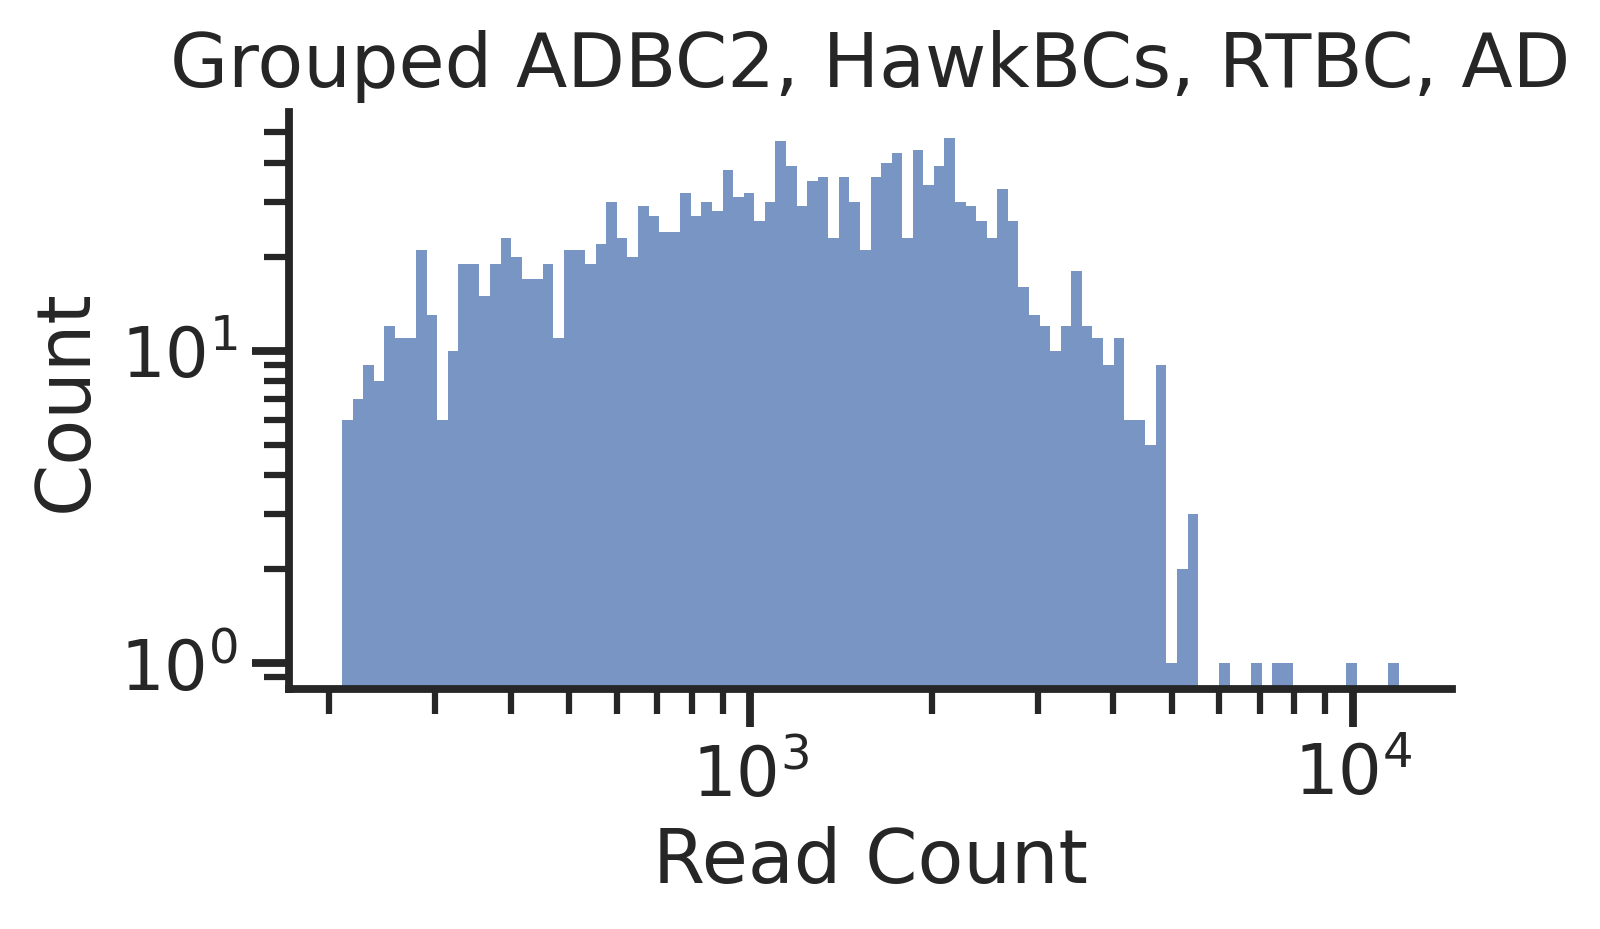

Done in 0.57 seconds.

Thresholding...
Using reads threshold of 1.


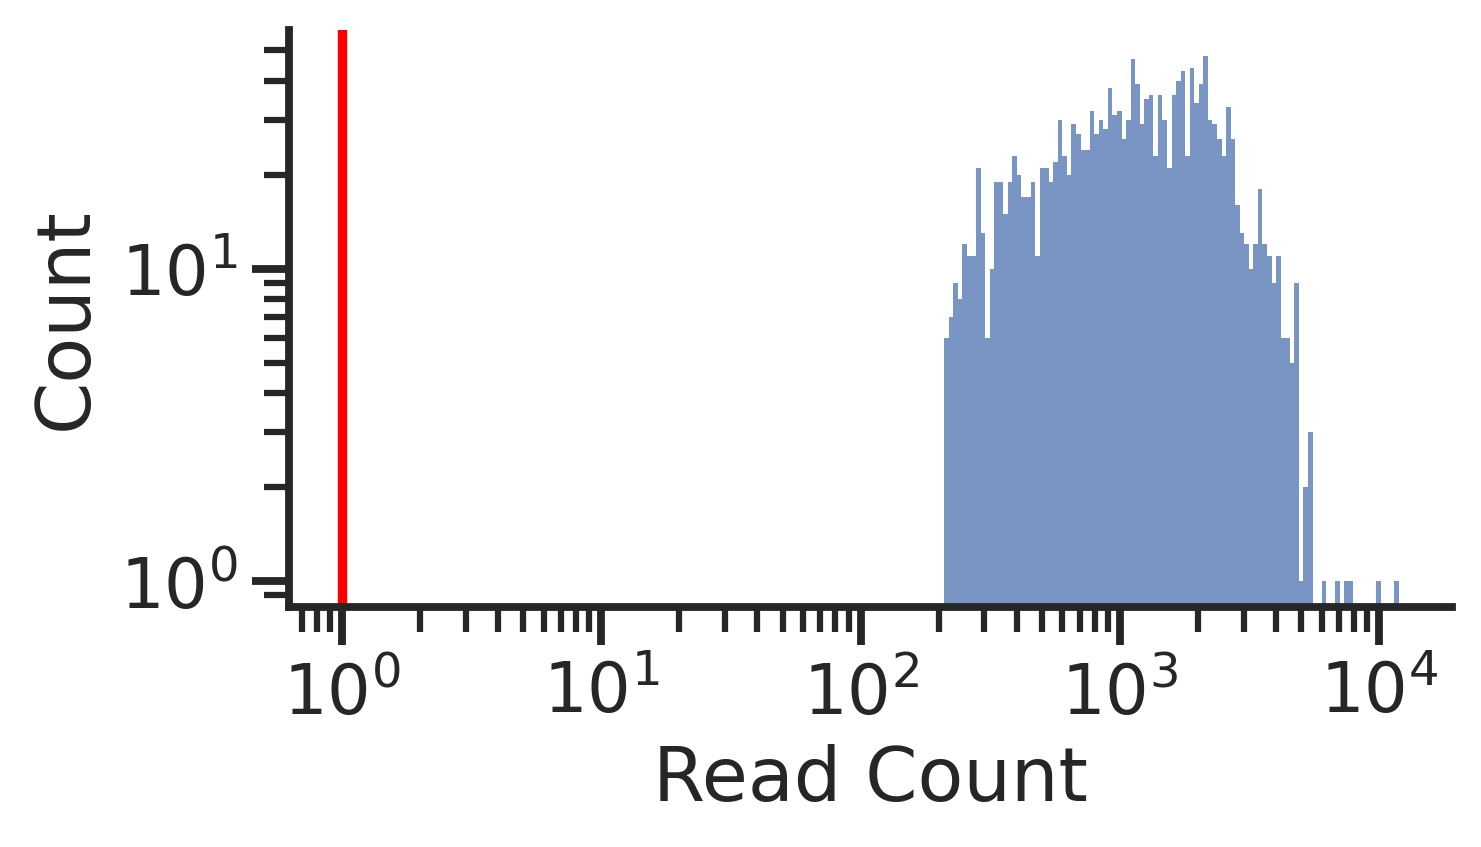

Done in 0.55 seconds.

Filtering so that at least 100% of reads come from the most abundant target...
	Processing mapping 1: ADBC2 || '-' || HawkBCs → AD
	Processing mapping 2: RTBC → ADBC2 || '-' || HawkBCs
Created filtered table: step1_ADBC2_HawkBCs_RTBC_AD_unique_target
Done in 0.04 seconds.


Filtering to designed sequences...
Created table: step1_ADBC2_HawkBCs_RTBC_AD_designed — kept only Designed == 1.
Done in 0.01 seconds.

Done.
Saved loss summary table as 'step1_ADBC2_HawkBCs_RTBC_AD_loss_summary'
Done in 0.09 seconds.



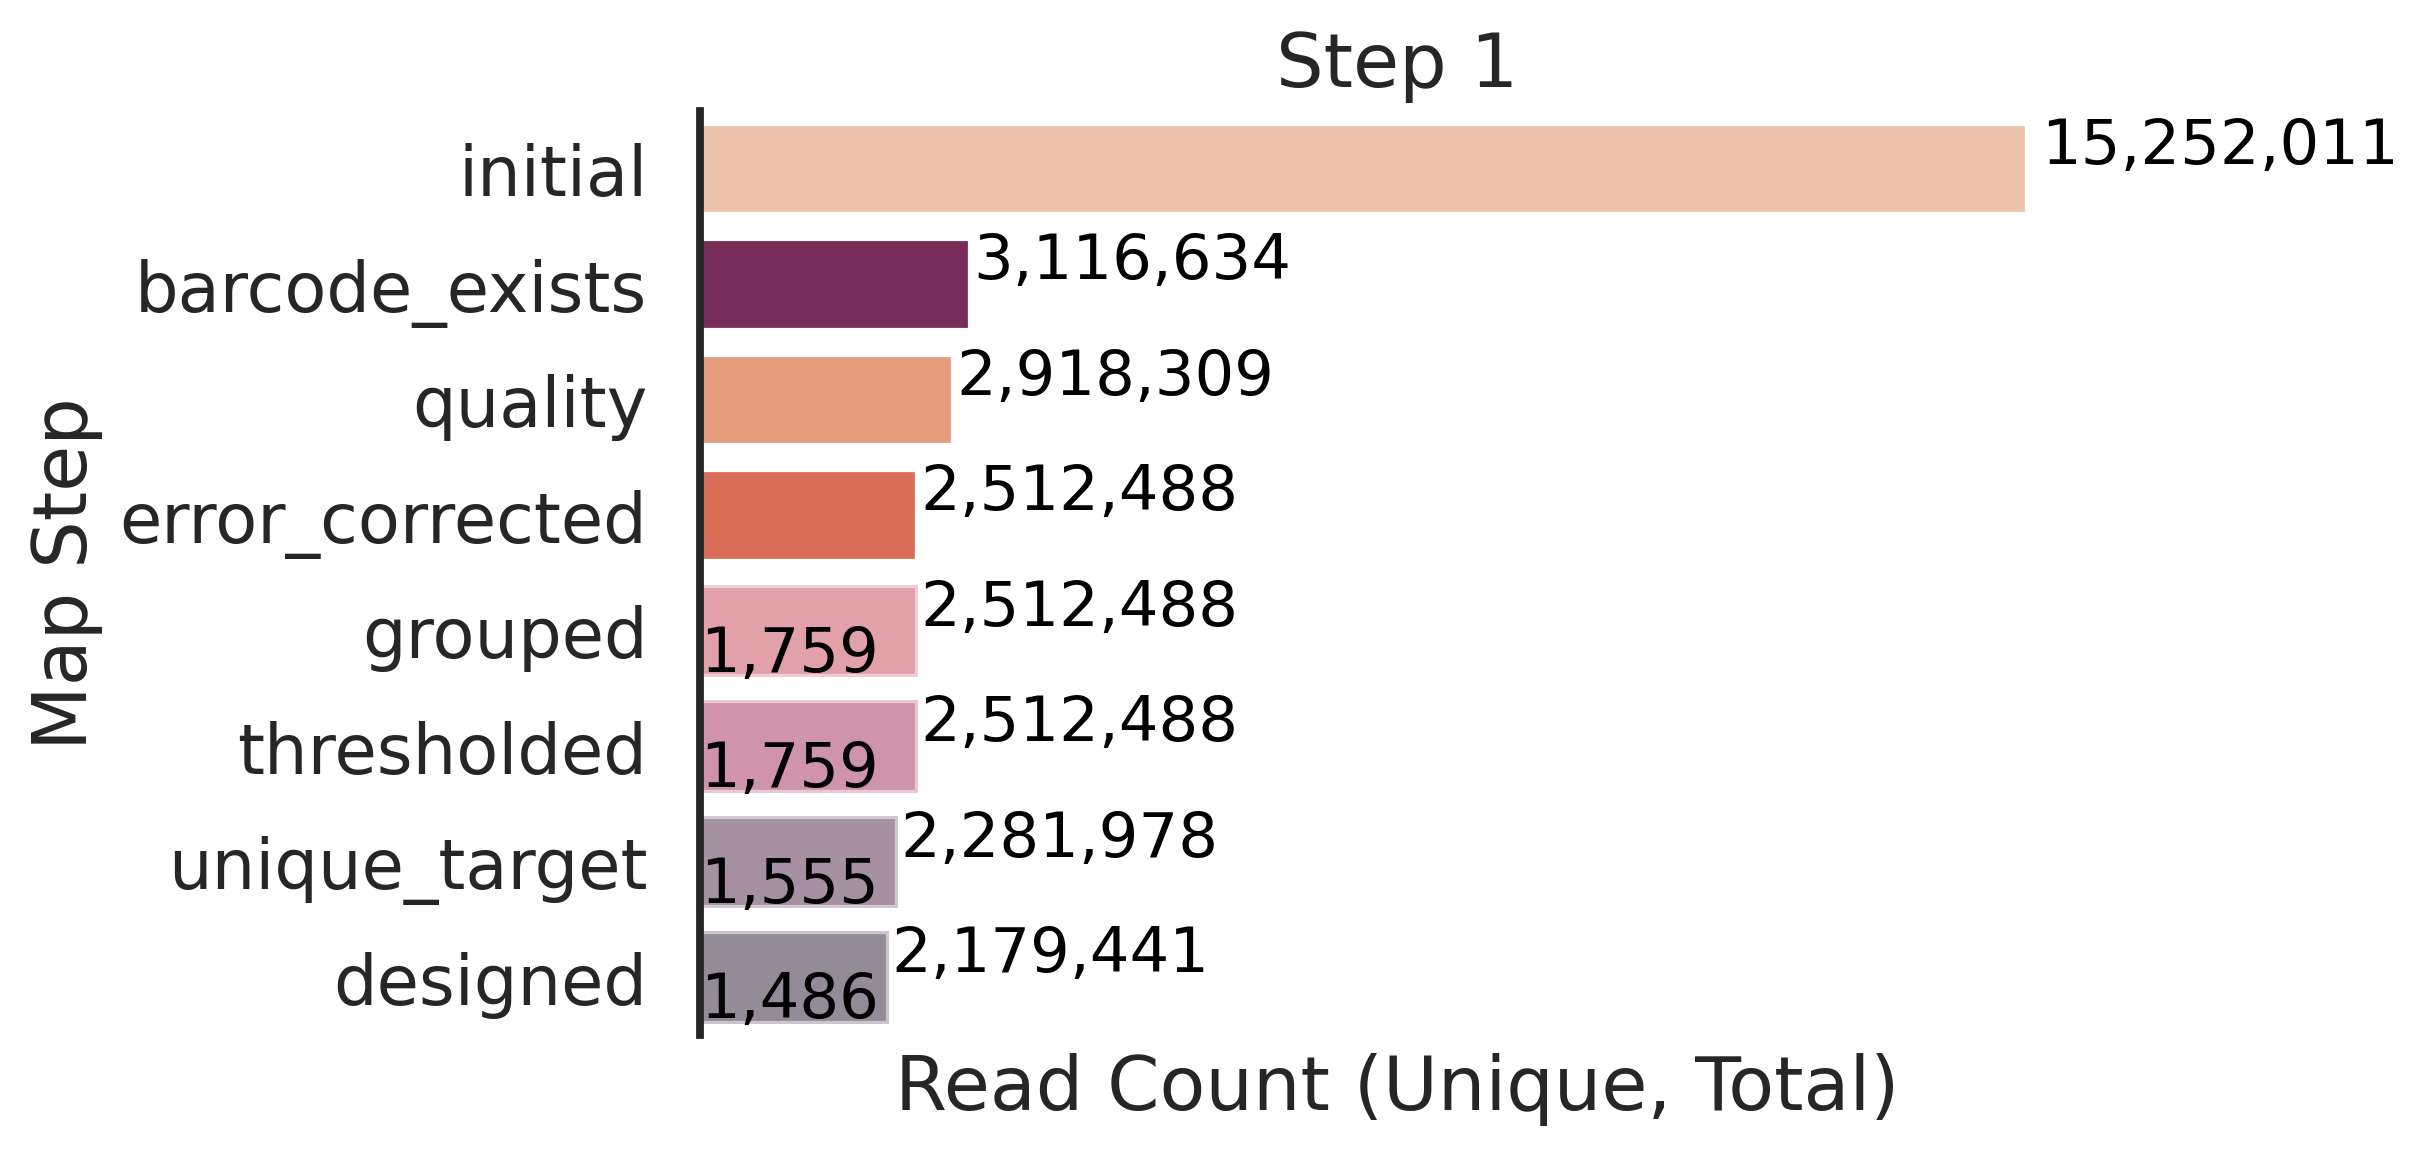

In [164]:
step1_map_err_corr = pipeline_err_corr_stringent.run_step_1(seq_file = ['/global/scratch/projects/fc_mvslab/OpenProjects/Caitlin/L4/S1_czb/TL4_S1_and_gDNA_RP48hr_puro_rep1_S21.fastq.gz.assembled.fastq'],
                    bc_objects = [step1_ADBC2, step1_HawkBCs, step1_RTBC, step1_AD],
                    column_pairs = [(("ADBC2", "HawkBCs"), "AD"), ( "RTBC", ("ADBC2", "HawkBCs"))],
                    reads_threshold = 1,
                    reverse_complement = False,
                    min_fraction_major_target = 1)

In [165]:
step1_map_err_corr = step1_map_err_corr[["ADBC2", "HawkBCs", "RTBC", "AD"]].drop_duplicates()
step1_map_err_corr

,ADBC2,HawkBCs,RTBC,AD
0,TGTACA,ATTCTCGCC,ATACGATGATTAATAT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...
1,GTAATC,CAGCGGTAT,CCCCAGGCACTATAAG,GCCCAGGACCTGGACGACGACACCTTCCAGGCCGGCATTCCCTTCA...
2,ACGTAT,AGTGTGCGT,ACAGGCTGTCGCTACC,GCCCAGGACCTGGCCGCCGCCAAGTTCCAGGCCGGCATTCCCTTCA...
3,TCAGTA,ACCGTTACC,AATGGGCCCGATCTAA,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...
4,ACGTTA,CCGTGATAC,TGTGCCAATCAAGGCA,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...
...,...,...,...,...
1481,CGGATT,ACGCAATCC,TGTAGGCCCGATAGCT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...
1482,TAATTC,AAGCTGCGA,GGATCTGCAGCTCTGA,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...
1483,TCACAG,AGTCCTCCT,TATTAACTACGAAAAA,TATCCCACCGCCCATCCTCTGGTGCAGGCCCAGCAGTGGACCTGGC...
1484,TCAAAT,AACTCCGTA,GTATAGGAAGCTTATA,CAGTTCGCCCTGACCGCCGCCGACGCCCAGGCCGGCATTCCCTTCA...


In [166]:
step1_map_err_corr["AD"].value_counts()

AD
GCCCTGGACCTGGCCGCCGCCACCTTCCTGGCCGGCATTCCCTTCAGCGCCTACAGCGCCCTGAGCCTGCTGCACATGCTGTACAACGCCCTGTACAGCAGCGCCAGCACACCTCTGTATCCCACCGCCCATCCTCTGGTGCTGGCCCTGCTGTGGACCTGG    16
GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCAGCGCCTACAGCGCCCAGAGCCTGCAGCACATGCAGTACAACGCCCAGTACAGCAGCGCCAGCACACCTCAGTATCCCACCCTGCATCCTCTGGTGCAGGCCCAGCAGTGGACCTGG    15
GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCAGCGCCTACAGCGCCCAGAGCCTGCAGCACATGCAGTACAACGCCCAGTACAGCAGCGCCAGCACACCTCAGTATCCCACCGCCCATCCTCTGGTGCAGGCCCAGCAGTGGACCTGG    13
GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCAGCGCCTACAGCGCCCAGAGCCTGCAGCACATGCAGTACAACTTCCAGTACAGCAGCGCCAGCACACCTCAGTATCCCACCGCCCATCCTCTGGTGCAGGCCCAGCAGTGGACCTGG    13
GCTCCCGACCTGGCCGCCGCCACCTTTCCCGCCGGCATTCCCTTCAGCGCCTACAGCGCTCCCAGCCTGCCTCACATGCCCTACAACGCTCCCTACAGCAGCGCCAGCACACCTCCCTATCCCACCGCCCATCCTCTGGTGCCCGCTCCTCCCTGGACCTGG    12
                                                                                                                                                        

# Step 1 with Hawk BC only

✓ Initial map already exists: step1_ADBC2_HawkBCs_RTBC_AD_initial — skipping
Base prefix (stable across descriptors): step1_ADBC2_HawkBCs_RTBC_AD_
Full prefix for this instance: step1_ADBC2_HawkBCs_RTBC_AD_

Using the following step order:
1. initial
2. barcode_exists
3. quality
4. error_corrected
5. grouped
6. thresholded
7. unique_target
8. designed

Removing rows with null or empty barcodes (excluding AD)...
Done in 1.71 seconds.


Filtering to high-quality reads...
Created table: step1_ADBC2_HawkBCs_RTBC_AD_quality — filtered for TRUE in all *_qual columns.
Done in 3.07 seconds.


=== Running error correction step on step1_ADBC2_HawkBCs_RTBC_AD_quality ===

=== Applying whitelist for step1 ===
Generating FASTQ: /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/NKX2-2/stringent_step1/figures/step1_ADBC2_HawkBCs_RTBC_AD_filtered_barcodes_extracted.fastq
Wrote 2918309 reads to /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/NKX2-2/stringent_step

/global/home/users/sanjanakotha/.local/lib/python3.11/site-packages/umi_tools/whitelist_methods.py:207: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  fig3.set_xlim(0, len(counts)*1.25)


Whitelist complete.
- Log: /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/NKX2-2/stringent_step1/figures/step1_ADBC2_HawkBCs_RTBC_AD_filtered_barcodes_extracted_whitelist.log
- Output: /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/NKX2-2/stringent_step1/figures/step1_ADBC2_HawkBCs_RTBC_AD_filtered_barcodes_extracted_whitelist.txt
- Plots: /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/NKX2-2/stringent_step1/figures/step1_ADBC2_HawkBCs_RTBC_AD_filtered_barcodes_extracted_plots_*.png
Unique canonical barcodes: 1759
Merging with design file...
Done in 3.88 seconds.

Whitelist application complete for step1 at step1_ADBC2_HawkBCs_RTBC_AD_error_corrected
Done in 2.70 minutes.

Grouping step1_ADBC2_HawkBCs_RTBC_AD_error_corrected...


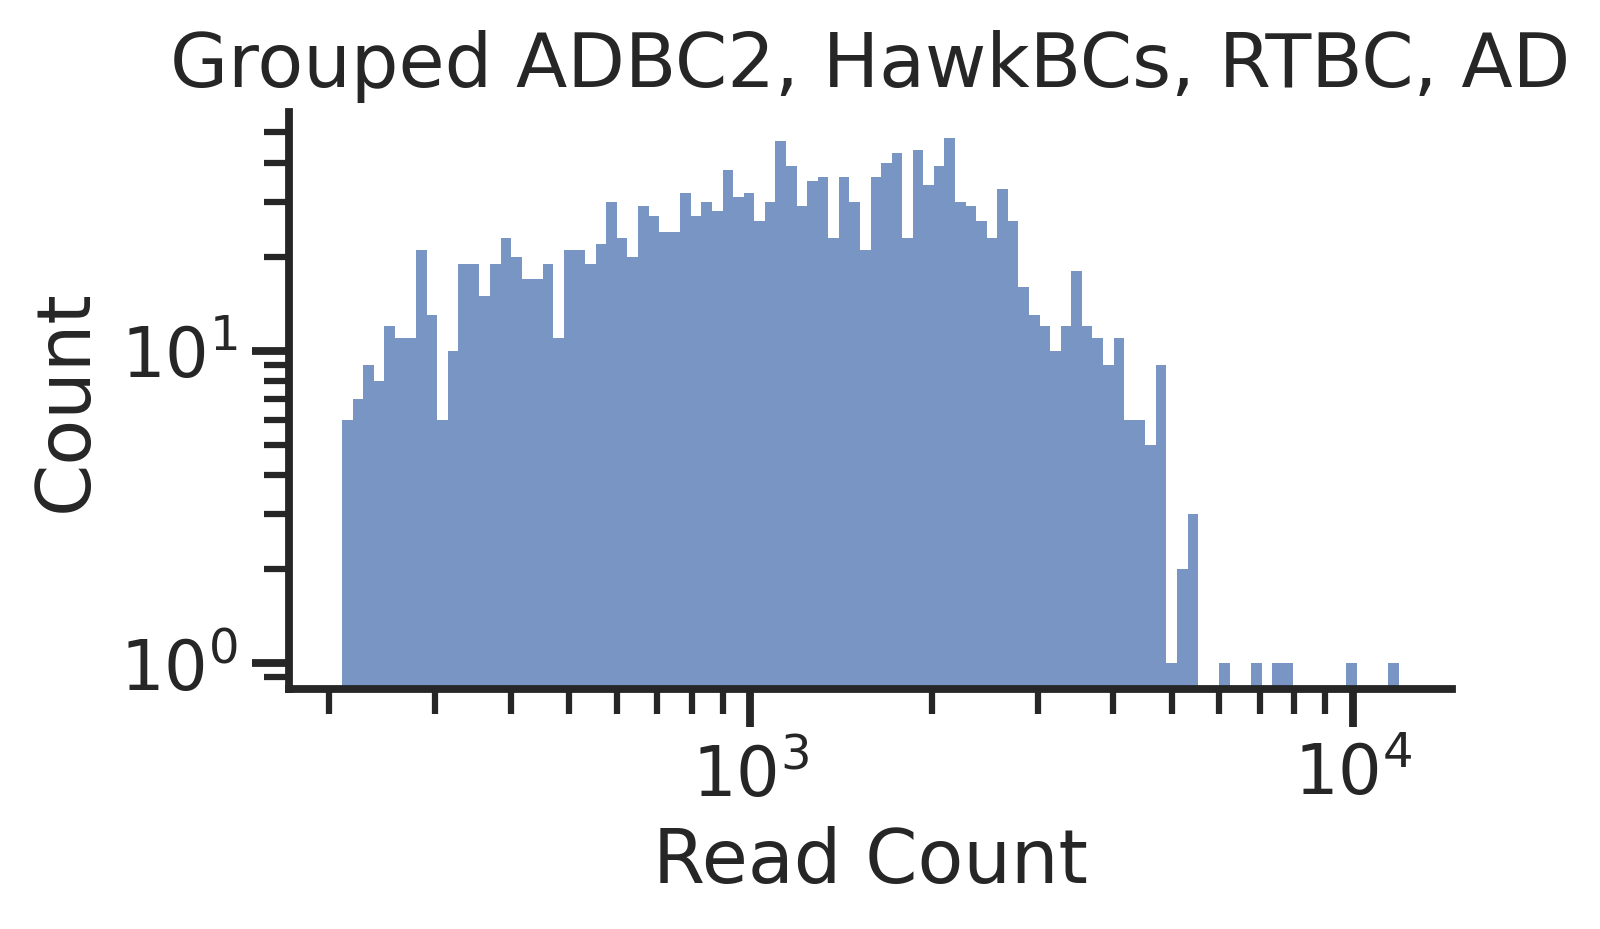

Done in 0.59 seconds.

Thresholding...
Using reads threshold of 1.


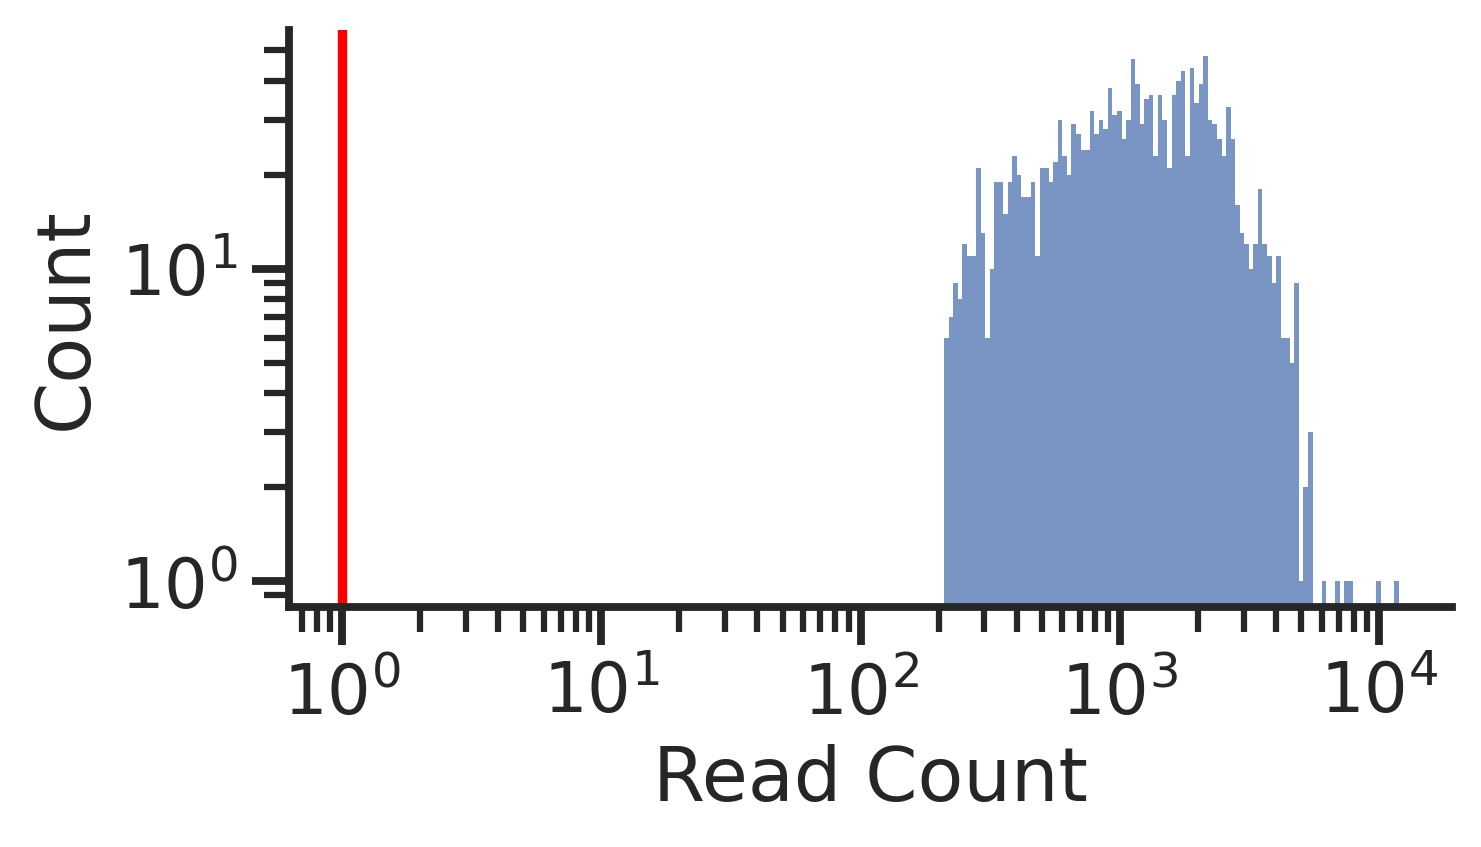

Done in 0.52 seconds.

Filtering so that at least 100% of reads come from the most abundant target...
	Processing mapping 1: HawkBCs → AD
	Processing mapping 2: RTBC → HawkBCs
Created filtered table: step1_ADBC2_HawkBCs_RTBC_AD_unique_target
Done in 0.04 seconds.


Filtering to designed sequences...
Created table: step1_ADBC2_HawkBCs_RTBC_AD_designed — kept only Designed == 1.
Done in 0.02 seconds.

Done.
Saved loss summary table as 'step1_ADBC2_HawkBCs_RTBC_AD_loss_summary'
Done in 0.15 seconds.



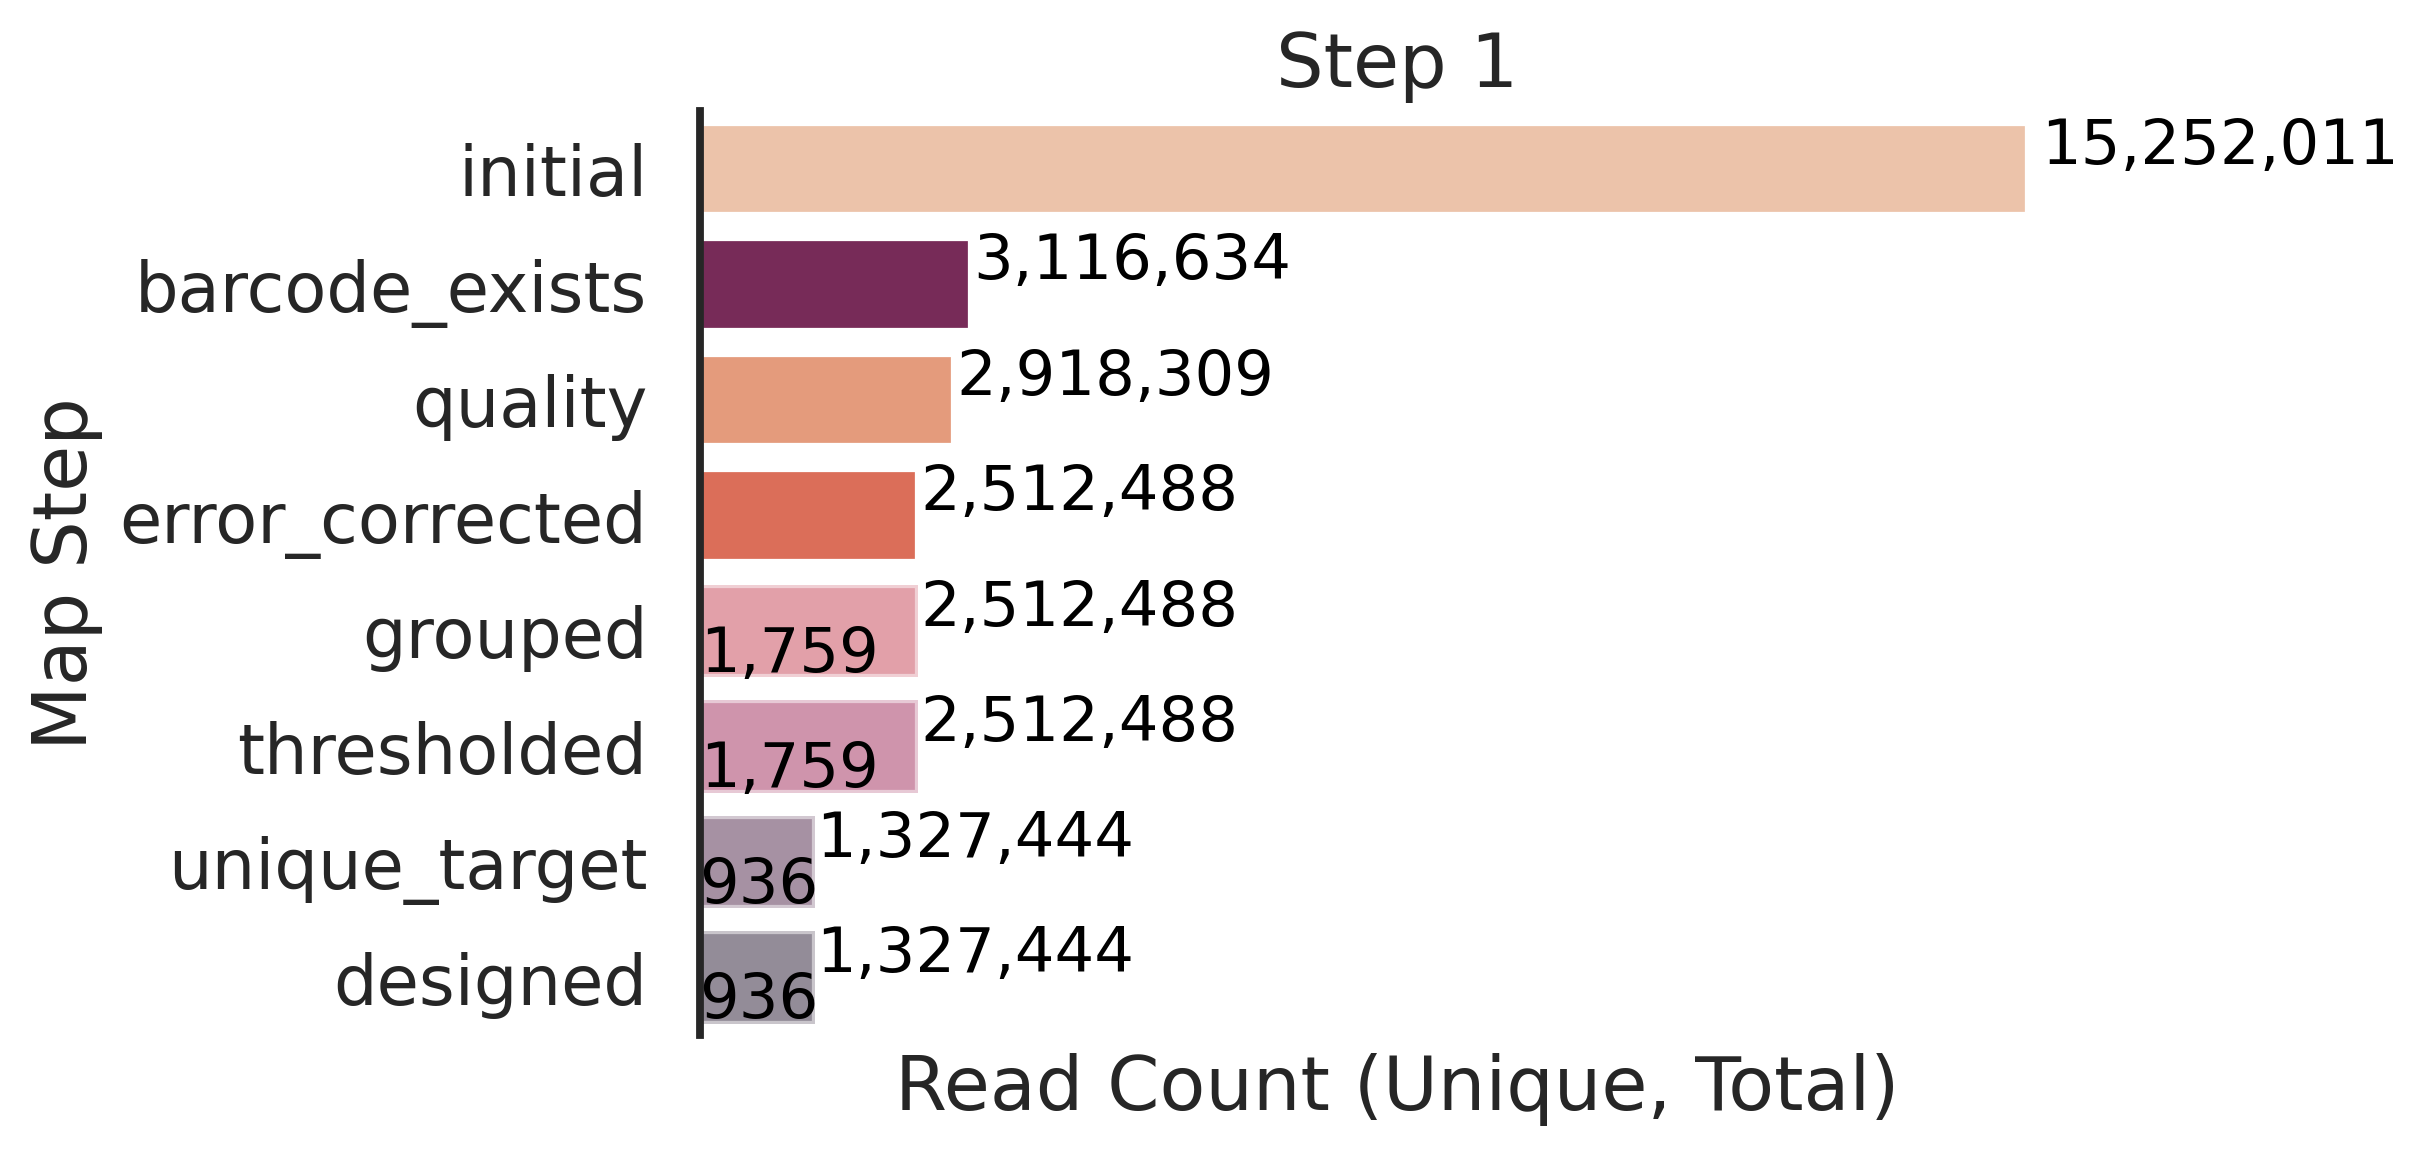

In [181]:
step1_map_err_corr_hawk = pipeline_err_corr_stringent.run_step_1(seq_file = ['/global/scratch/projects/fc_mvslab/OpenProjects/Caitlin/L4/S1_czb/TL4_S1_and_gDNA_RP48hr_puro_rep1_S21.fastq.gz.assembled.fastq'],
                    bc_objects = [step1_ADBC2, step1_HawkBCs, step1_RTBC, step1_AD],
                    column_pairs = [(("HawkBCs"), "AD"), ( "RTBC", ("HawkBCs"))],
                    reads_threshold = 1,
                    reverse_complement = False,
                    min_fraction_major_target = 1)

In [184]:
step1_map_err_corr_hawk = step1_map_err_corr_hawk[["HawkBCs", "RTBC", "AD"]].drop_duplicates()
step1_map_err_corr_hawk

,HawkBCs,RTBC,AD
0,ATTCTCGCC,ATACGATGATTAATAT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...
1,CAGCGGTAT,CCCCAGGCACTATAAG,GCCCAGGACCTGGACGACGACACCTTCCAGGCCGGCATTCCCTTCA...
2,ACCGTTACC,AATGGGCCCGATCTAA,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...
3,CCGTGATAC,TGTGCCAATCAAGGCA,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...
4,CCGATCTAT,TGCTGAGTGTCGAATT,ACCGACTTCATCGACGAGGAGGTGCTGATGAGCCTGGTGATCGAGA...
...,...,...,...
931,AGCCTTGTC,CAGTGTCCAAAGGCAA,CCCTTCAGCGCCTACAGCGCCCAGAGCCTGCAGCACATGGCCCAGG...
932,ACGCAATCC,TGTAGGCCCGATAGCT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...
933,AAGCTGCGA,GGATCTGCAGCTCTGA,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...
934,AGTCCTCCT,TATTAACTACGAAAAA,TATCCCACCGCCCATCCTCTGGTGCAGGCCCAGCAGTGGACCTGGC...


In [185]:
step1_map_err_corr_hawk["AD"].value_counts()

AD
GCCCTGGACCTGGCCGCCGCCACCTTCCTGGCCGGCATTCCCTTCAGCGCCTACAGCGCCCTGAGCCTGCTGCACATGCTGTACAACGCCCTGTACAGCAGCGCCAGCACACCTCTGTATCCCACCGCCCATCCTCTGGTGCTGGCCCTGCTGTGGACCTGG    17
GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCAGCGCCTACAGCGCCCAGAGCCTGCAGCACATGCAGTACAACGCCCAGTACAGCAGCGCCAGCACACCTCAGTATCCCACCGCCCATCCTCTGGTGTTCGCCCAGCAGTGGACCTGG    14
GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCAGCGCCTACAGCGCCCAGAGCCTGCAGCACATGCAGTACAACGCCCAGTACAGCAGCGCCAGCACACCTCAGTATCCCACCCTGCATCCTCTGGTGCAGGCCCAGCAGTGGACCTGG    14
ACCGACTTCATCGACGAGGAGGTGTTCATGAGCTTCGTGATCGAGATGGGCTTCGACAGAATCAAGGAGTTTCCCGAGTTCTGGTTCGGCCAGAACGAGTTCGACTTCATGACCGACGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGC    14
CAGTTCGCCCTGACCGCCGCCGACGCCCAGGCCGGCATTCCCTTCAGCGCCTACAGCGCCCAGAGCCTGCAGCACATGCAGTACAACGCCCAGTACAGCAGCGCCAGCACACCTCAGTATCCCACCGCCCATCCTCTGGTGCAGGCCCAGCAGTGGACCTGG    13
                                                                                                                                                        

# Step 1 map with ADBC2 Only

✓ Initial map already exists: step1_ADBC2_HawkBCs_RTBC_AD_initial — skipping
Base prefix (stable across descriptors): step1_ADBC2_HawkBCs_RTBC_AD_
Full prefix for this instance: step1_ADBC2_HawkBCs_RTBC_AD_

Using the following step order:
1. initial
2. barcode_exists
3. quality
4. error_corrected
5. grouped
6. thresholded
7. unique_target
8. designed

Removing rows with null or empty barcodes (excluding AD)...
Done in 2.00 seconds.


Filtering to high-quality reads...
Created table: step1_ADBC2_HawkBCs_RTBC_AD_quality — filtered for TRUE in all *_qual columns.
Done in 3.19 seconds.


=== Running error correction step on step1_ADBC2_HawkBCs_RTBC_AD_quality ===

=== Applying whitelist for step1 ===
Generating FASTQ: /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/NKX2-2/stringent_step1/figures/step1_ADBC2_HawkBCs_RTBC_AD_filtered_barcodes_extracted.fastq
Wrote 2918309 reads to /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/NKX2-2/stringent_step

/global/home/users/sanjanakotha/.local/lib/python3.11/site-packages/umi_tools/whitelist_methods.py:207: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  fig3.set_xlim(0, len(counts)*1.25)


Whitelist complete.
- Log: /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/NKX2-2/stringent_step1/figures/step1_ADBC2_HawkBCs_RTBC_AD_filtered_barcodes_extracted_whitelist.log
- Output: /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/NKX2-2/stringent_step1/figures/step1_ADBC2_HawkBCs_RTBC_AD_filtered_barcodes_extracted_whitelist.txt
- Plots: /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/NKX2-2/stringent_step1/figures/step1_ADBC2_HawkBCs_RTBC_AD_filtered_barcodes_extracted_plots_*.png
Unique canonical barcodes: 1759
Merging with design file...
Done in 3.91 seconds.

Whitelist application complete for step1 at step1_ADBC2_HawkBCs_RTBC_AD_error_corrected
Done in 2.64 minutes.

Grouping step1_ADBC2_HawkBCs_RTBC_AD_error_corrected...


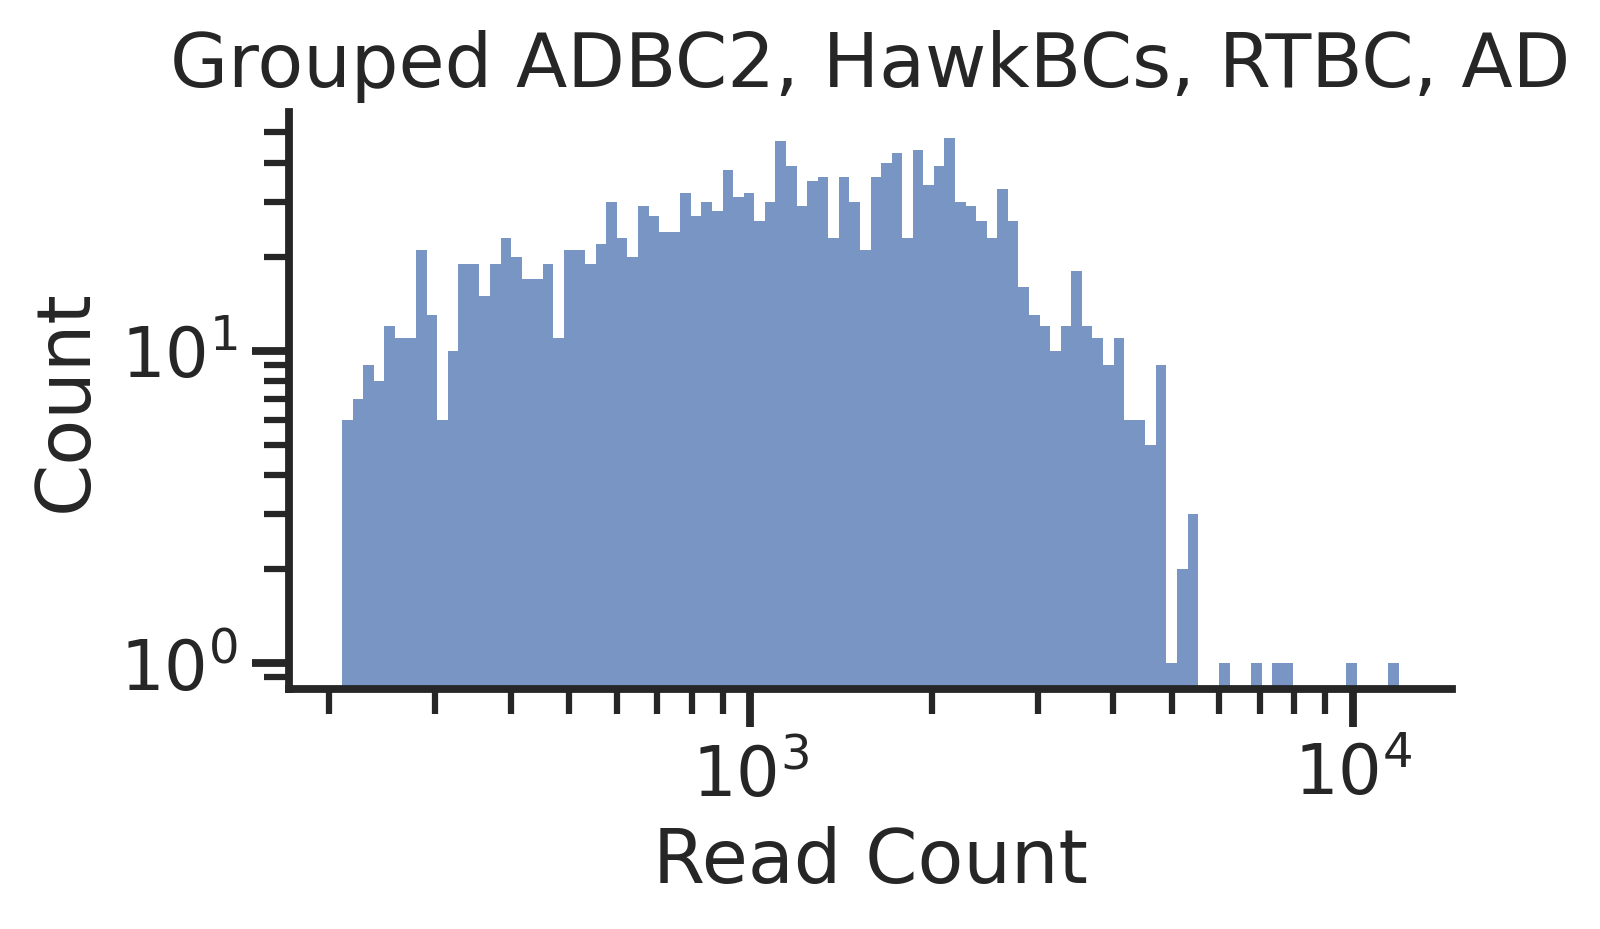

Done in 0.56 seconds.

Thresholding...
Using reads threshold of 1.


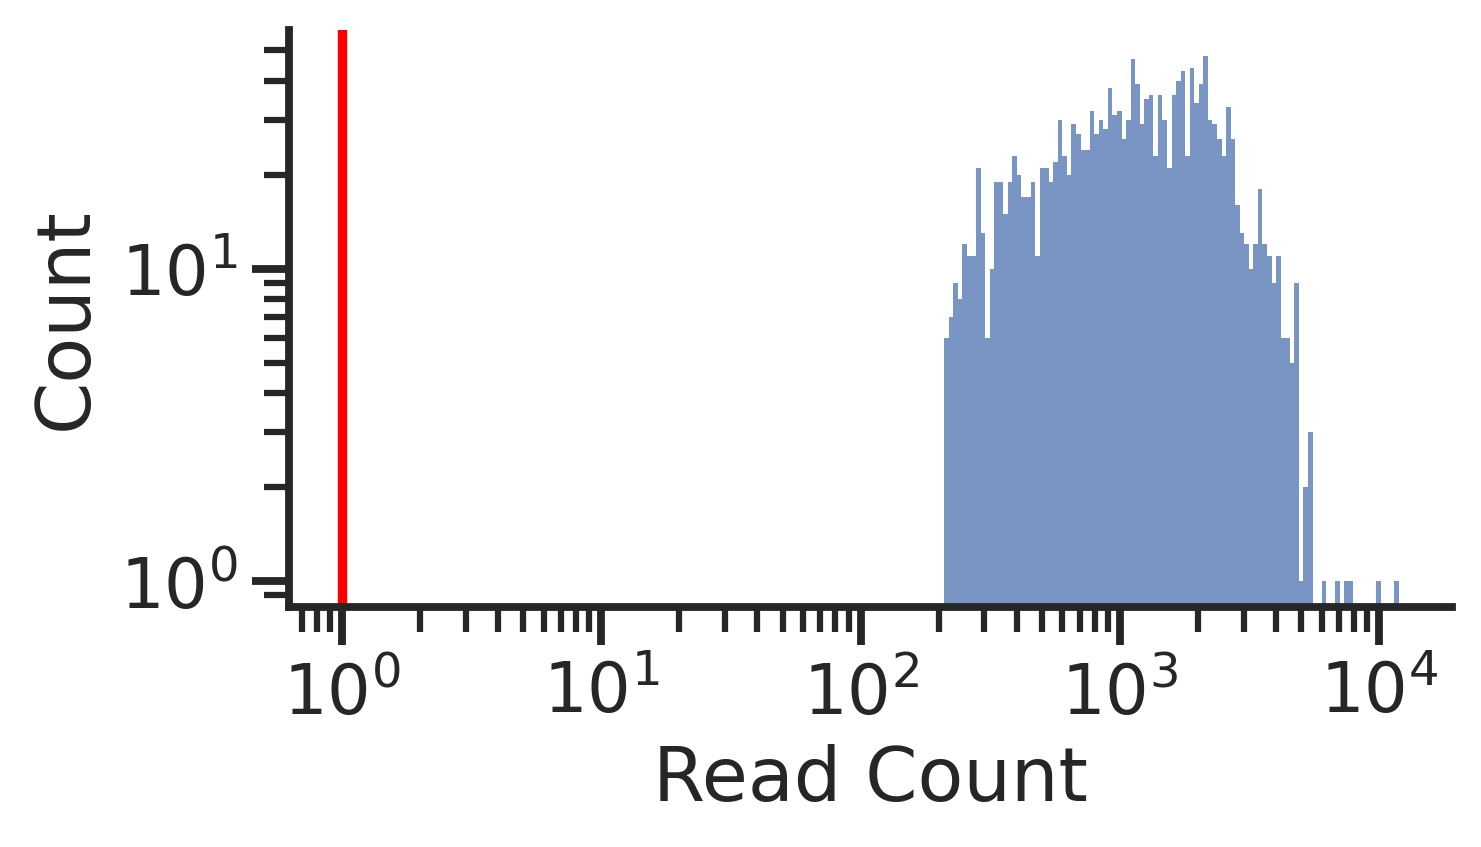

Done in 0.54 seconds.

Filtering so that at least 100% of reads come from the most abundant target...
	Processing mapping 1: ADBC2 → AD
	Processing mapping 2: RTBC → ADBC2
Created filtered table: step1_ADBC2_HawkBCs_RTBC_AD_unique_target
Done in 0.03 seconds.


Filtering to designed sequences...
Created table: step1_ADBC2_HawkBCs_RTBC_AD_designed — kept only Designed == 1.
Done in 0.02 seconds.

Done.
Saved loss summary table as 'step1_ADBC2_HawkBCs_RTBC_AD_loss_summary'
Done in 0.08 seconds.



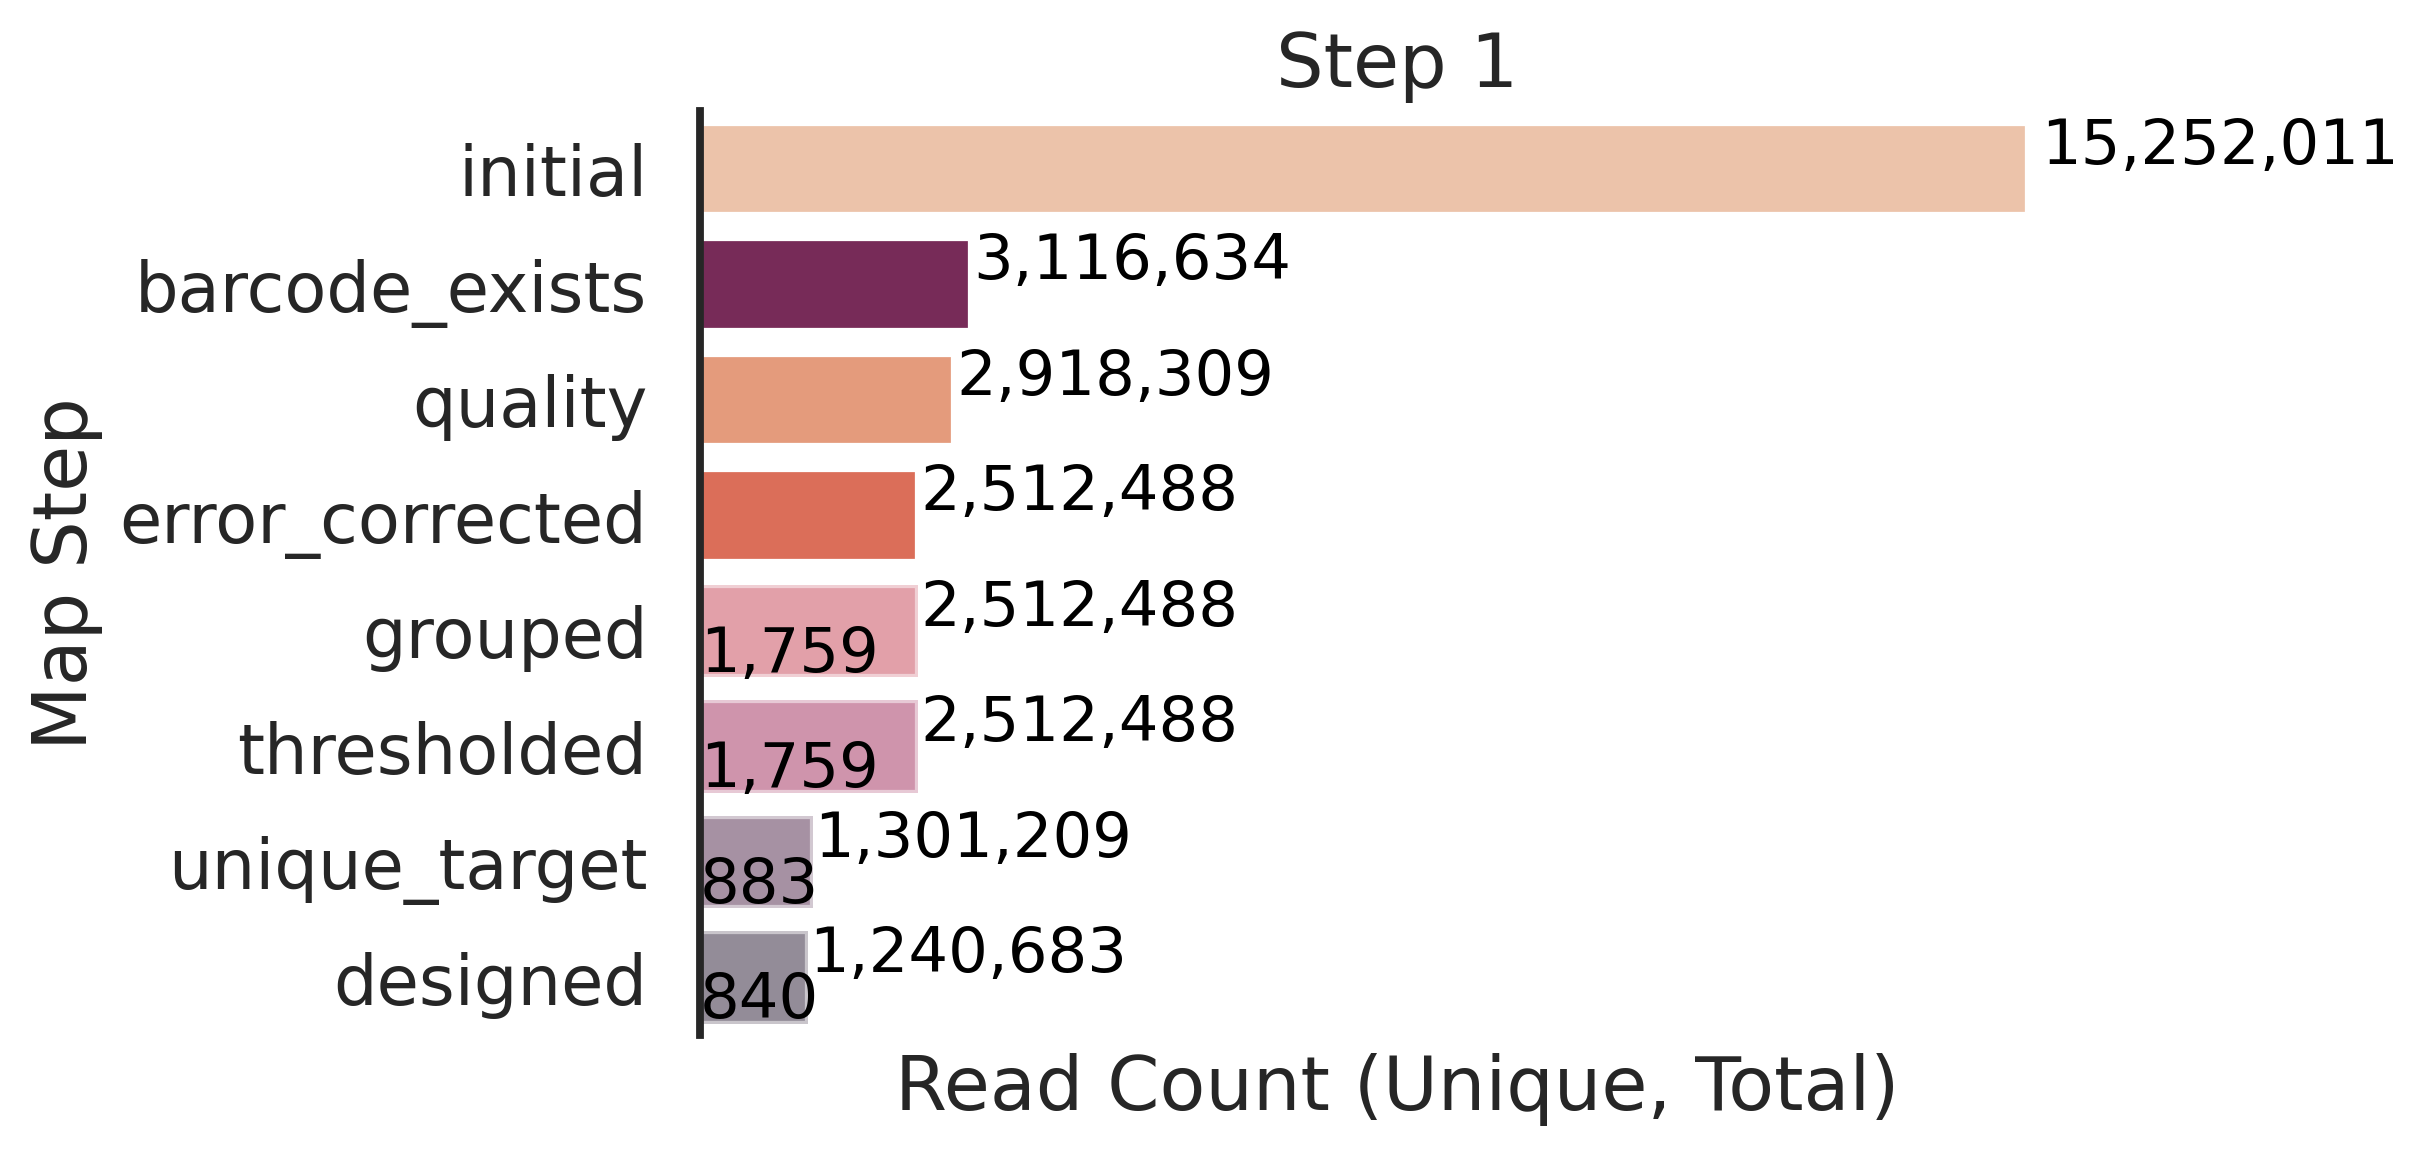

In [186]:
step1_map_err_corr_adbc2 = pipeline_err_corr_stringent.run_step_1(seq_file = ['/global/scratch/projects/fc_mvslab/OpenProjects/Caitlin/L4/S1_czb/TL4_S1_and_gDNA_RP48hr_puro_rep1_S21.fastq.gz.assembled.fastq'],
                    bc_objects = [step1_ADBC2, step1_HawkBCs, step1_RTBC, step1_AD],
                    column_pairs = [(("ADBC2"), "AD"), ( "RTBC", ("ADBC2"))],
                    reads_threshold = 1,
                    reverse_complement = False,
                    min_fraction_major_target = 1)

In [187]:
step1_map_err_corr_adbc2 = step1_map_err_corr_adbc2[["HawkBCs", "RTBC", "AD"]].drop_duplicates()
step1_map_err_corr_adbc2

,HawkBCs,RTBC,AD
0,ATTCTCGCC,ATACGATGATTAATAT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...
1,AGTGTGCGT,ACAGGCTGTCGCTACC,GCCCAGGACCTGGCCGCCGCCAAGTTCCAGGCCGGCATTCCCTTCA...
2,AATCGTGCC,TTCAGAGGCATATGGA,GCCCAGGACCTGGCCGCCGCCACCGCCCAGGCCGGCATTCCCTTCA...
3,ACCGCTCAT,GAACGAAATAGGAGTG,GCCCAGGACCTGGCCGCCAGCACCTTCCAGGCCGGCATTCCCTTCA...
4,ACGCTACTT,CATATCGGAATTCTCT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...
...,...,...,...
835,AGCCTTGTC,CAGTGTCCAAAGGCAA,CCCTTCAGCGCCTACAGCGCCCAGAGCCTGCAGCACATGGCCCAGG...
836,ACGCAATCC,TGTAGGCCCGATAGCT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...
837,AAGCTGCGA,GGATCTGCAGCTCTGA,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...
838,AACTCCGTA,GTATAGGAAGCTTATA,CAGTTCGCCCTGACCGCCGCCGACGCCCAGGCCGGCATTCCCTTCA...


In [188]:
step1_map_err_corr_adbc2["AD"].value_counts()

AD
GCCCTGGACCTGGCCGCCGCCACCTTCCTGGCCGGCATTCCCTTCAGCGCCTACAGCGCCCTGAGCCTGCTGCACATGCTGTACAACGCCCTGTACAGCAGCGCCAGCACACCTCTGTATCCCACCGCCCATCCTCTGGTGCTGGCCCTGCTGTGGACCTGG    12
GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCAGCGCCTACAGCGCCCAGAGCCTGCAGCACATGCAGTACAACGCCCAGTACAGCAGCGCCAGCACACCTCAGTATCCCACCCTGCATCCTCTGGTGCAGGCCCAGCAGTGGACCTGG    10
GCCCAGGACCTGGCCTTCGCCACCTTCCAGGCCGGCATTCCCTTCAGCGCCTACAGCGCCCAGAGCCTGCAGCACATGCAGTACAACGCCCAGTACAGCAGCGCCAGCACACCTCAGTATCCCACCGCCCATCCTCTGGTGCAGGCCCAGCAGTGGACCTGG     9
GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCGCCGCCTACAGCGCCCAGAGCCTGCAGCACATGCAGTACAACGCCCAGTACAGCAGCGCCAGCACACCTCAGTATCCCACCGCCCATCCTCTGGTGCAGGCCCAGCAGTGGACCTGG     8
GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCAGCGCCTACAGCGCCCAGAGCCTGCAGCACATGCAGTACAACGCCCAGTACAGCAGCGCCAGCACACCTCAGTATCCCACCGCCCATCCTCTGGTGCAGCTGCAGCAGTGGACCTGG     8
                                                                                                                                                        

# TREBL Experiment Analysis

## Puro only, Hawk + ADBC

In [196]:
#  Read in puro RT results and format
puro_RT_trebl_results = pd.read_csv("../../output/NKX2-2/TL4B2/puro_only/err_corr_100/RT_trebl_experiment_results.csv")
puro_RT_trebl_results["rep"] = puro_RT_trebl_results["name"].str.extract("_R(\d+)_")
puro_RT_trebl_results["time"] = puro_RT_trebl_results["name"].str.extract("_T(.*)_").astype(int)
puro_RT_trebl_results = puro_RT_trebl_results.drop(columns = ['name', "RTBC_umi_count_simple"])

# Merge with step 1
puro_RT_trebl_results_step1 = pd.merge(step1_map_err_corr, puro_RT_trebl_results)
puro_RT_trebl_results_step1

,HawkBCs,RTBC,AD,RTBC_umi_count_complex,rep,time
0,ATTCTCGCC,ATACGATGATTAATAT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,77,1,4
1,ATTCTCGCC,ATACGATGATTAATAT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,944,2,24
2,ATTCTCGCC,ATACGATGATTAATAT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,1857,1,48
3,ATTCTCGCC,ATACGATGATTAATAT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,34,3,4
4,ATTCTCGCC,ATACGATGATTAATAT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,85,2,4
...,...,...,...,...,...,...
11867,AATGAGAGG,CTTGATAGGGCTGGGC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,379,2,24
11868,AATGAGAGG,CTTGATAGGGCTGGGC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,22,1,48
11869,AATGAGAGG,CTTGATAGGGCTGGGC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,73,2,4
11870,AATGAGAGG,CTTGATAGGGCTGGGC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,16,1,24


In [201]:
# Read in puro AD results and format
puro_AD_trebl_results = pd.read_csv("../../output/NKX2-2/TL4B2/puro_only/err_corr_100/AD_trebl_experiment_results.csv")
puro_AD_trebl_results["rep"] = puro_AD_trebl_results["name"].str.extract("_R(\d+)_")
puro_AD_trebl_results["time"] = puro_AD_trebl_results["name"].str.extract("_T(.*)_").astype(int)
puro_AD_trebl_results = puro_AD_trebl_results.drop(columns = ['name', "AD_umi_count_simple", "AD_ADBC_concat"])
puro_AD_trebl_results

,AD_umi_count_complex,ADBC2,HawkBCs,rep,time
0,17160,TGACAC,ATACCGTCG,4,48
1,957,TTAAGG,ATATGCCTC,4,48
2,46053,TTAGGC,CAACAGTGC,4,48
3,21554,CTAGAA,CAATGTGAC,4,48
4,23136,AAACTG,CATTCCAAG,4,48
...,...,...,...,...,...
13903,15,CCGATC,CACAACTTC,1,48
13904,29,ACAAGC,CAACAGTGC,1,48
13905,14,ACTCAA,CAATCTCTC,1,48
13906,21,ATCTCA,CAGACAGCA,1,48


In [202]:
# Merge with step 1
puro_AD_trebl_results_step1 = pd.merge(step1_map_err_corr, puro_AD_trebl_results)
puro_AD_trebl_results_step1

,HawkBCs,RTBC,AD,AD_umi_count_complex,ADBC2,rep,time
0,ATTCTCGCC,ATACGATGATTAATAT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,1404,TGTACA,4,48
1,ATTCTCGCC,ATACGATGATTAATAT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,941,GCGCTT,4,48
2,ATTCTCGCC,ATACGATGATTAATAT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,39,ACGGAC,4,48
3,ATTCTCGCC,ATACGATGATTAATAT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,404,TGTACA,3,48
4,ATTCTCGCC,ATACGATGATTAATAT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,44,AAATTA,3,48
...,...,...,...,...,...,...,...
100793,AATGAGAGG,CTTGATAGGGCTGGGC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,2709,TTAGCA,2,48
100794,AATGAGAGG,CTTGATAGGGCTGGGC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,315,CGAGCA,2,48
100795,AATGAGAGG,CTTGATAGGGCTGGGC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,1766,AGGGAG,2,48
100796,AATGAGAGG,CTTGATAGGGCTGGGC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,521,ACCATC,2,48


In [203]:
# Calculate activity scores
puro_trebl_results = pd.merge(puro_AD_trebl_results_step1, puro_RT_trebl_results_step1, how = 'outer').fillna(0)
puro_trebl_results["activity"] = (puro_trebl_results["RTBC_umi_count_complex"] + 1) / (puro_trebl_results["AD_umi_count_complex"] + 1)
puro_trebl_results

,HawkBCs,RTBC,AD,AD_umi_count_complex,ADBC2,rep,time,RTBC_umi_count_complex,activity
0,AACAACACC,AAGTCGAGATATAAAG,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,25.0,AAGTTC,1,0,0.0,0.038462
1,AACAACACC,AAGTCGAGATATAAAG,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,95.0,TATTAT,1,4,0.0,0.010417
2,AACAACACC,AAGTCGAGATATAAAG,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,119.0,CGTTTA,1,4,0.0,0.008333
3,AACAACACC,AAGTCGAGATATAAAG,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,23.0,GACAAG,1,4,0.0,0.041667
4,AACAACACC,AAGTCGAGATATAAAG,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,93.0,AAGTTC,1,4,0.0,0.010638
...,...,...,...,...,...,...,...,...,...
101626,CCGTTCAGA,CTTAGAAACATTTTTA,GGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCA...,579.0,CTGCAC,4,4,165.0,0.286207
101627,CCGTTCAGA,CTTAGAAACATTTTTA,GGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCA...,91.0,CTGCAC,4,24,692.0,7.532609
101628,CCGTTCAGA,CTTAGAAACATTTTTA,GGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCA...,4819.0,TACCAC,4,24,692.0,0.143776
101629,CCGTTCAGA,CTTAGAAACATTTTTA,GGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCA...,4909.0,TACCAC,4,48,324.0,0.066191


In [204]:
# Aggregate RT transcripts per AD BC
RT_aggreg_puro_trebl_results = puro_trebl_results.drop(columns = "RTBC").groupby(["ADBC2", "HawkBCs", "AD", "rep", "time"]).sum().reset_index()
RT_aggreg_puro_trebl_results["activity"] = (RT_aggreg_puro_trebl_results["RTBC_umi_count_complex"] + 1) / (RT_aggreg_puro_trebl_results["AD_umi_count_complex"] + 1)
RT_aggreg_puro_trebl_activities = RT_aggreg_puro_trebl_results[["AD", "rep", "time", "activity"]].groupby(["AD", "rep", "time"]).agg([np.mean, np.std]).reset_index().dropna()
RT_aggreg_puro_trebl_activities.columns = ["AD", "rep", "time", "mean", "std"]
RT_aggreg_puro_trebl_activities

,AD,rep,time,mean,std
4,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...,3,4,0.032389,0.008588
5,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...,4,24,0.008209,0.003435
6,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...,4,48,0.018635,0.020786
8,ACCGACTTCATCGACGAGGAGGTGATCATGAGCATCGTGATCGAGA...,1,4,0.992900,1.108686
9,ACCGACTTCATCGACGAGGAGGTGATCATGAGCATCGTGATCGAGA...,1,24,15.243922,20.556640
...,...,...,...,...,...
3362,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,3,24,1.556010,2.163967
3363,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,3,48,0.588047,0.624482
3365,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,4,4,0.477047,0.510775
3366,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,4,24,2.405590,2.755141


Text(0.5, 1.0, 'TREBL Experiment using Step 1\nStringent Collision Check & Error Correction')

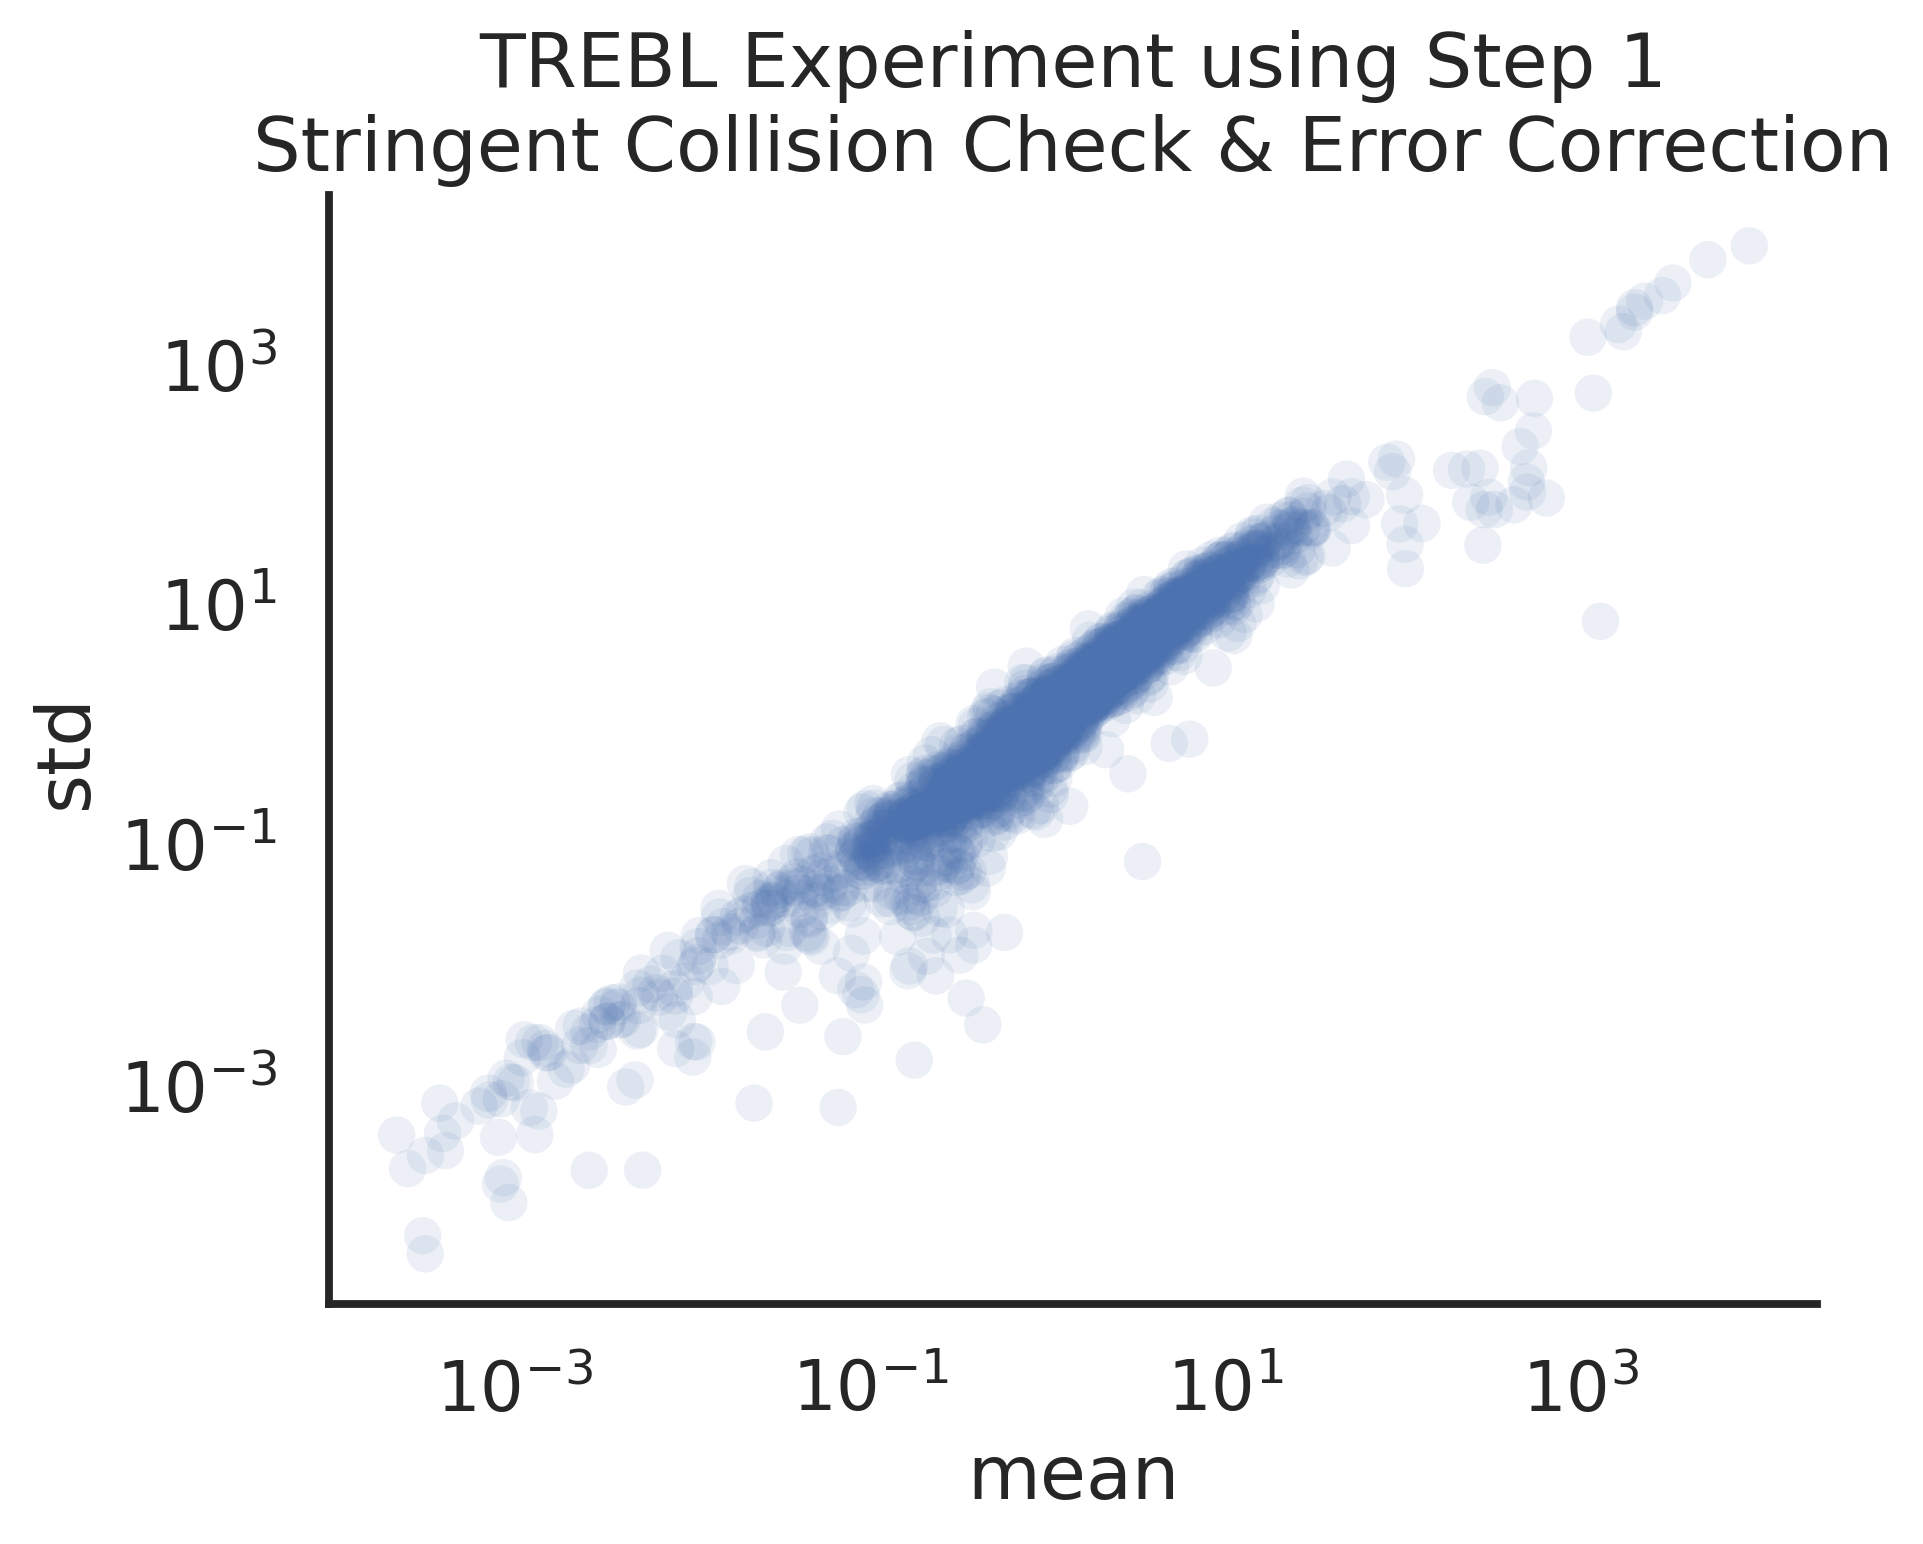

In [287]:
plt.figure(dpi = 300)
ax = sns.scatterplot(data = RT_aggreg_puro_trebl_activities, x = "mean", y = "std", edgecolor = 'none', alpha = 0.1)
ax.set_xscale('log')
ax.set_yscale('log')
sns.despine()
plt.title("TREBL Experiment using Step 1\nStringent Collision Check & Error Correction")

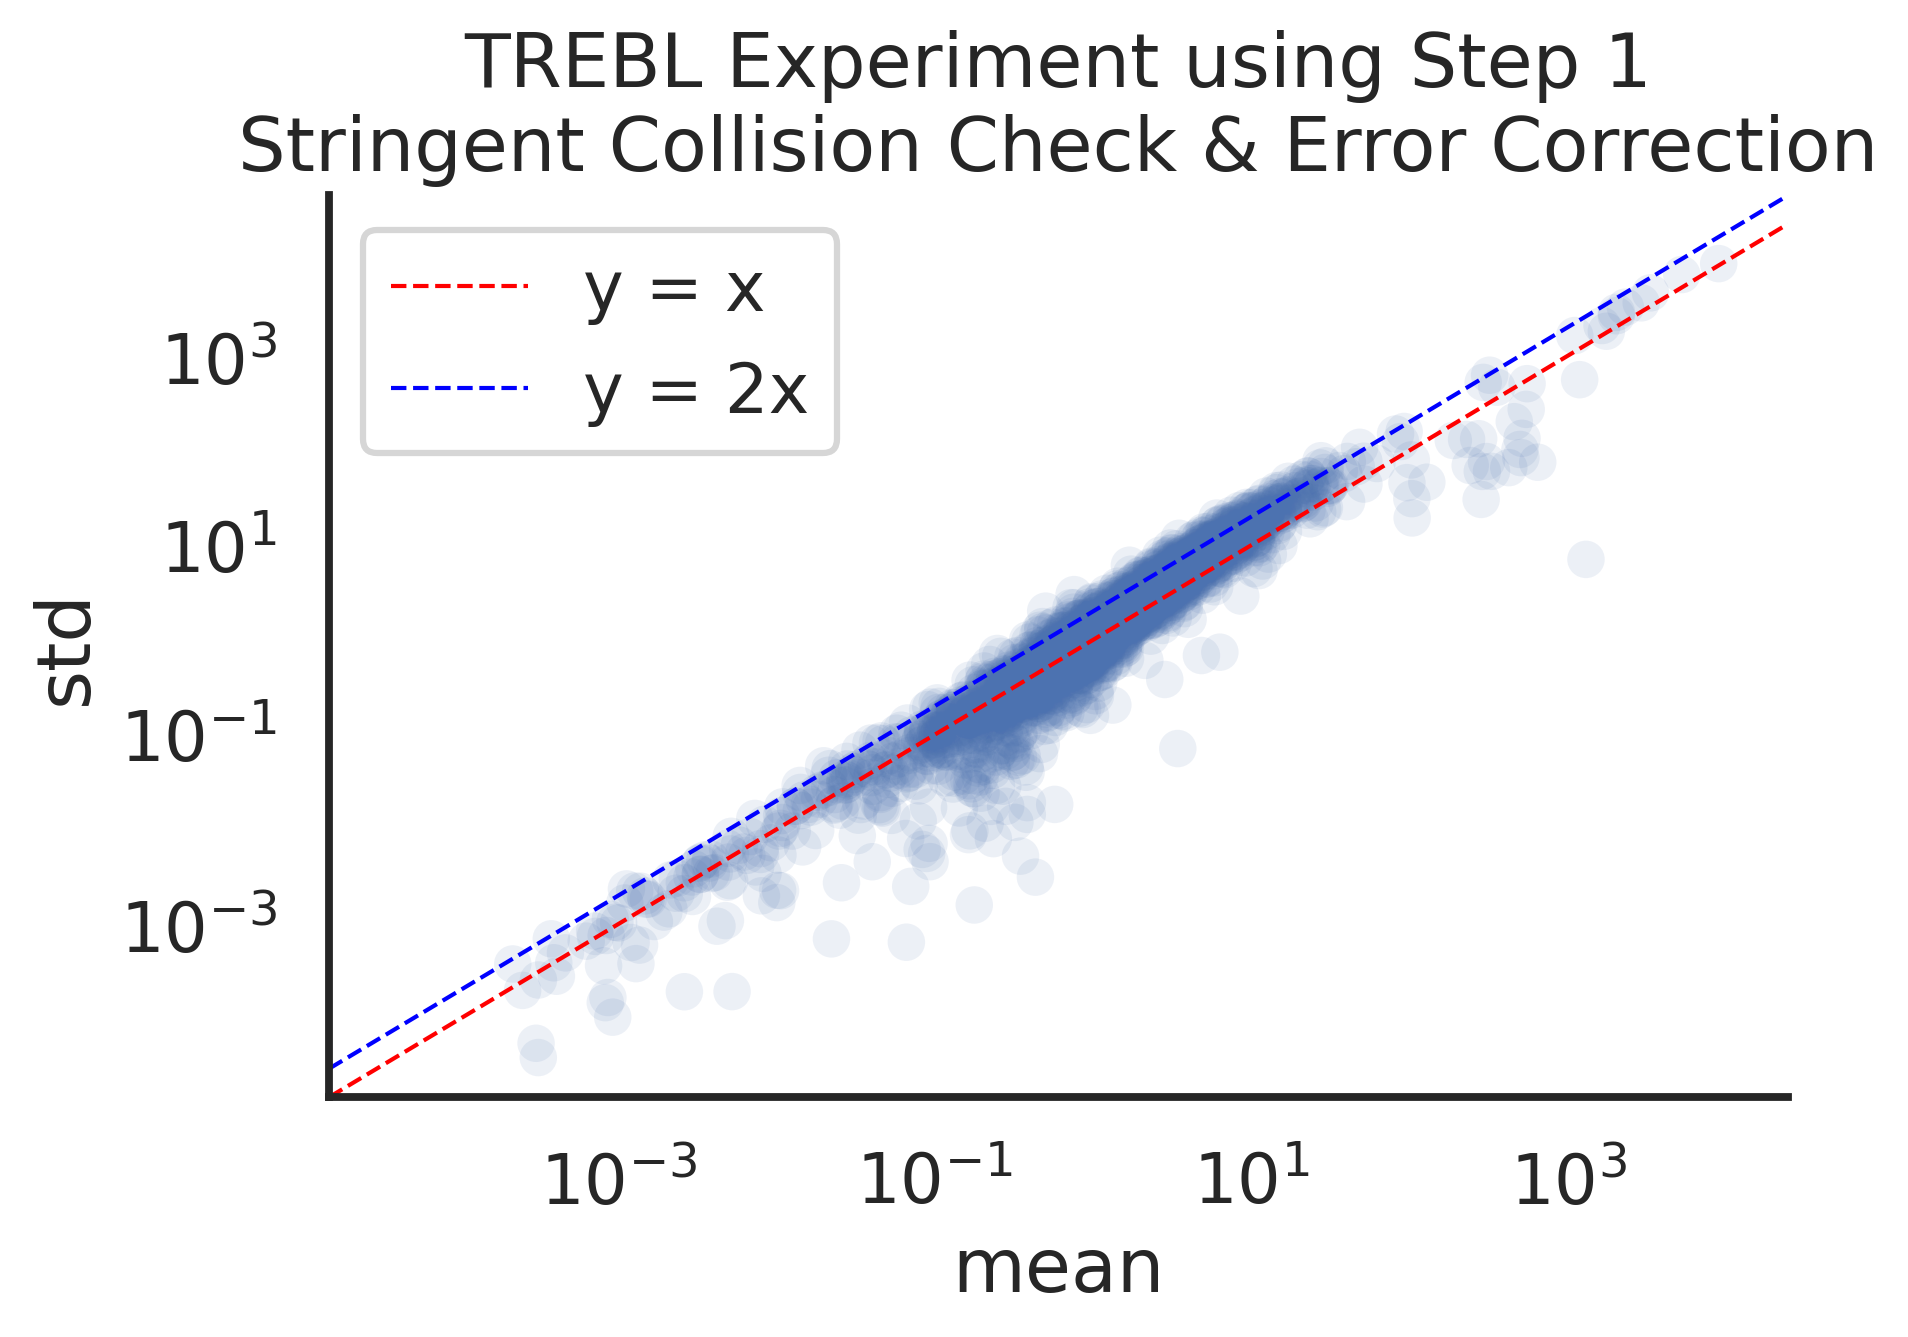

In [290]:
plt.figure(dpi=300)
ax = sns.scatterplot(
    data=RT_aggreg_puro_trebl_activities,
    x="mean",
    y="std",
    edgecolor='none',
    alpha=0.1
)

# Set log scales
ax.set_xscale('log')
ax.set_yscale('log')

# Determine limits for plotting lines
lims = [
    np.min([ax.get_xlim()[0], ax.get_ylim()[0]]),
    np.max([ax.get_xlim()[1], ax.get_ylim()[1]])
]

# Plot y = x line
ax.plot(lims, lims, color='red', linestyle='--', linewidth=1, label='y = x')

# Plot y = 2x line
ax.plot(lims, [2*l for l in lims], color='blue', linestyle='--', linewidth=1, label='y = 2x')

# Ensure limits include both lines
ax.set_xlim(lims)
ax.set_ylim([lims[0], lims[1]*2])  # extend y-limit to fit y=2x

sns.despine()
plt.legend()
plt.title("TREBL Experiment using Step 1\nStringent Collision Check & Error Correction")
plt.tight_layout()
plt.show()

# Hawk only - no biological replicates though!

In [265]:
step1_map_err_corr_hawk[["AD", "HawkBCs"]].drop_duplicates().value_counts()

AD                                                                                                                                                                  HawkBCs  
ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGATGGGCGCCGACAGAATCAAGGAGGCTCCCGAGGCCGCCGCCGGCCAGAACGAGGCCGACGCCATGACCGACGCCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGC  CCGTGATAC    1
ACCGACTTCATCGACGAGGAGGTGCTGATGAGCCTGGTGATCGAGATGGGCCTGGACAGAATCAAGGAGCTGCCCGAGCTGTGGCTGGGCCAGAACGAGTTCGACTTCATGACCGACTTCGGCAGCGGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGC  CCGATCTAT    1
ACCGACTTCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGATGGGCGCCGACAGAATCAAGGAGGCTCCCGAGGCCTGGGCCGGCCAGAACGAGTTCGACTTCATGACCGACTTCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGC  CCGGAGAAT    1
ACCGACTTCATCGACGAGGAGGTGTTCATGAGCTTCGTGATCGAGATGGGCTTCGACAGAATCAAGGAGTTTCCCGAGTTCTGGTTCGGCCAGAACGAGTTCGACTTCATGACCGACGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGC  CATTCGTAC    1
ACCGCCTTCATCGCCGCCGCCGTGCTGATGAGCCTGGTGATCGCCATGGGCCTGGCCAGAATCAAGGAGCTGCCCGAGCTGTGGCTGGGCCAGAACGAGTTCGACTTCAT

In [266]:
# Merge with step 1
puro_RT_trebl_results_step1_hawk = pd.merge(step1_map_err_corr_hawk, puro_RT_trebl_results)
puro_RT_trebl_results_step1_hawk

,HawkBCs,RTBC,AD,RTBC_umi_count_complex,rep,time
0,ATTCTCGCC,ATACGATGATTAATAT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,77,1,4
1,ATTCTCGCC,ATACGATGATTAATAT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,944,2,24
2,ATTCTCGCC,ATACGATGATTAATAT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,1857,1,48
3,ATTCTCGCC,ATACGATGATTAATAT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,34,3,4
4,ATTCTCGCC,ATACGATGATTAATAT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,85,2,4
...,...,...,...,...,...,...
7251,AACTCCGTA,GTATAGGAAGCTTATA,CAGTTCGCCCTGACCGCCGCCGACGCCCAGGCCGGCATTCCCTTCA...,4,1,48
7252,AACTCCGTA,GTATAGGAAGCTTATA,CAGTTCGCCCTGACCGCCGCCGACGCCCAGGCCGGCATTCCCTTCA...,953,4,48
7253,AACTCCGTA,GTATAGGAAGCTTATA,CAGTTCGCCCTGACCGCCGCCGACGCCCAGGCCGGCATTCCCTTCA...,11,1,0
7254,AACTCCGTA,GTATAGGAAGCTTATA,CAGTTCGCCCTGACCGCCGCCGACGCCCAGGCCGGCATTCCCTTCA...,182,4,4


In [267]:
# Merge with step 1
puro_AD_trebl_results_step1_hawk = pd.merge(step1_map_err_corr_hawk, puro_AD_trebl_results.drop(columns = ["ADBC2"]).groupby(["HawkBCs", "rep", "time"]).sum().reset_index())
puro_AD_trebl_results_step1_hawk

,HawkBCs,RTBC,AD,rep,time,AD_umi_count_complex
0,ATTCTCGCC,ATACGATGATTAATAT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,1,0,30
1,ATTCTCGCC,ATACGATGATTAATAT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,1,4,987
2,ATTCTCGCC,ATACGATGATTAATAT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,1,24,4294
3,ATTCTCGCC,ATACGATGATTAATAT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,2,0,336
4,ATTCTCGCC,ATACGATGATTAATAT,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,2,4,1531
...,...,...,...,...,...,...
11572,AACTCCGTA,GTATAGGAAGCTTATA,CAGTTCGCCCTGACCGCCGCCGACGCCCAGGCCGGCATTCCCTTCA...,3,48,8897
11573,AACTCCGTA,GTATAGGAAGCTTATA,CAGTTCGCCCTGACCGCCGCCGACGCCCAGGCCGGCATTCCCTTCA...,4,0,1179
11574,AACTCCGTA,GTATAGGAAGCTTATA,CAGTTCGCCCTGACCGCCGCCGACGCCCAGGCCGGCATTCCCTTCA...,4,4,2382
11575,AACTCCGTA,GTATAGGAAGCTTATA,CAGTTCGCCCTGACCGCCGCCGACGCCCAGGCCGGCATTCCCTTCA...,4,24,7579


In [268]:
# Calculate activity scores
puro_trebl_results_hawk = pd.merge(puro_AD_trebl_results_step1_hawk, puro_RT_trebl_results_step1_hawk, how = 'outer').fillna(0)
puro_trebl_results_hawk["activity"] = (puro_trebl_results_hawk["RTBC_umi_count_complex"] + 1) / (puro_trebl_results_hawk["AD_umi_count_complex"] + 1)
puro_trebl_results_hawk

,HawkBCs,RTBC,AD,rep,time,AD_umi_count_complex,RTBC_umi_count_complex,activity
0,AACAACGGT,GACTACCGTTGGTAAG,TACAACGCCCAGTACAGCAGCGCCAGCACACCTCAGTATCCCACCG...,1,0,28.0,0.0,0.034483
1,AACAACGGT,GACTACCGTTGGTAAG,TACAACGCCCAGTACAGCAGCGCCAGCACACCTCAGTATCCCACCG...,1,4,89.0,0.0,0.011111
2,AACAACGGT,GACTACCGTTGGTAAG,TACAACGCCCAGTACAGCAGCGCCAGCACACCTCAGTATCCCACCG...,1,24,71.0,34.0,0.486111
3,AACAACGGT,GACTACCGTTGGTAAG,TACAACGCCCAGTACAGCAGCGCCAGCACACCTCAGTATCCCACCG...,1,48,0.0,12.0,13.000000
4,AACAACGGT,GACTACCGTTGGTAAG,TACAACGCCCAGTACAGCAGCGCCAGCACACCTCAGTATCCCACCG...,2,4,67.0,0.0,0.014706
...,...,...,...,...,...,...,...,...
12123,CCGTTCAGA,CTTAGAAACATTTTTA,GGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCA...,3,48,2526.0,64.0,0.025722
12124,CCGTTCAGA,CTTAGAAACATTTTTA,GGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCA...,4,0,25.0,0.0,0.038462
12125,CCGTTCAGA,CTTAGAAACATTTTTA,GGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCA...,4,4,1508.0,165.0,0.110007
12126,CCGTTCAGA,CTTAGAAACATTTTTA,GGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCA...,4,24,4910.0,692.0,0.141112


In [269]:
# Aggregate RT transcripts per AD BC
RT_aggreg_puro_trebl_results_hawk = puro_trebl_results_hawk.drop(columns = "RTBC").groupby(["HawkBCs", "AD", "rep", "time"]).sum().reset_index()
RT_aggreg_puro_trebl_results_hawk["activity"] = (RT_aggreg_puro_trebl_results_hawk["RTBC_umi_count_complex"] + 1) / (RT_aggreg_puro_trebl_results_hawk["AD_umi_count_complex"] + 1)
RT_aggreg_puro_trebl_activities_hawk = RT_aggreg_puro_trebl_results_hawk[["AD", "rep", "time", "activity"]].groupby(["AD", "rep", "time"]).agg([np.mean, np.std]).reset_index()#.dropna()
# RT_aggreg_puro_trebl_activities_hawk.columns = ["AD", "rep", "time", "mean", "std"]
RT_aggreg_puro_trebl_activities_hawk

AD rep time   activity  \
                                                                       mean   
0     ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...   1    0  25.000000   
1     ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...   1   24  26.000000   
2     ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...   2    4   0.116022   
3     ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...   2   24   0.234339   
4     ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...   2   48   0.187402   
...                                                 ...  ..  ...        ...   
1895  TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...   3   48   0.056483   
1896  TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...   4    0   0.002451   
1897  TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...   4    4   0.022334   
1898  TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...   4   24   0.063998   
1899  TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...   4   48   0.038692   

          
     std  
0    NaN  
1    NaN  
2    NaN  
3    NaN  
4    NaN  
...   ..  
1895 NaN  
1896 NaN  
1897 NaN  
1898 NaN  
1899 NaN  

[1900 rows x 5 columns]

In [253]:
RT_aggreg_puro_trebl_activities_hawk["AD"].iloc[0]

'ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGATGGGCGCCGACAGAATCAAGGAGGCTCCCGAGGCCGCCGCCGGCCAGAACGAGGCCGACGCCATGACCGACGCCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGC'

In [258]:
RT_aggreg_puro_trebl_results_hawk[RT_aggreg_puro_trebl_results_hawk["AD"] == RT_aggreg_puro_trebl_activities_hawk["AD"].iloc[1500]].sort_values(by = 'time')

,HawkBCs,AD,rep,time,AD_umi_count_complex,RTBC_umi_count_complex,activity
265,AAGTCTCAC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,1,0,1342.0,197.0,0.147431
272,AAGTCTCAC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,3,0,352.0,0.0,0.002833
276,AAGTCTCAC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,4,0,2750.0,177.0,0.064704
269,AAGTCTCAC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,2,4,0.0,14.0,15.000000
273,AAGTCTCAC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,3,4,15279.0,370.0,0.024280
277,AAGTCTCAC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,4,4,5203.0,461.0,0.088778
266,AAGTCTCAC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,1,4,7942.0,485.0,0.061186
270,AAGTCTCAC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,2,24,1045.0,340.0,0.326004
278,AAGTCTCAC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,4,24,48928.0,2515.0,0.051421
274,AAGTCTCAC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,3,24,23837.0,734.0,0.030833


In [252]:
RT_aggreg_puro_trebl_results_hawk

,HawkBCs,AD,rep,time,AD_umi_count_complex,RTBC_umi_count_complex,activity
0,AACAACGGT,TACAACGCCCAGTACAGCAGCGCCAGCACACCTCAGTATCCCACCG...,1,0,56.0,0.0,0.017544
1,AACAACGGT,TACAACGCCCAGTACAGCAGCGCCAGCACACCTCAGTATCCCACCG...,1,4,178.0,0.0,0.005587
2,AACAACGGT,TACAACGCCCAGTACAGCAGCGCCAGCACACCTCAGTATCCCACCG...,1,24,142.0,34.0,0.244755
3,AACAACGGT,TACAACGCCCAGTACAGCAGCGCCAGCACACCTCAGTATCCCACCG...,1,48,0.0,12.0,13.000000
4,AACAACGGT,TACAACGCCCAGTACAGCAGCGCCAGCACACCTCAGTATCCCACCG...,2,0,0.0,56.0,57.000000
...,...,...,...,...,...,...,...
1895,CCGTTCAGA,GGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCA...,3,48,7578.0,147.0,0.019528
1896,CCGTTCAGA,GGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCA...,4,0,75.0,0.0,0.013158
1897,CCGTTCAGA,GGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCA...,4,4,4524.0,165.0,0.036685
1898,CCGTTCAGA,GGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCA...,4,24,14730.0,692.0,0.047044


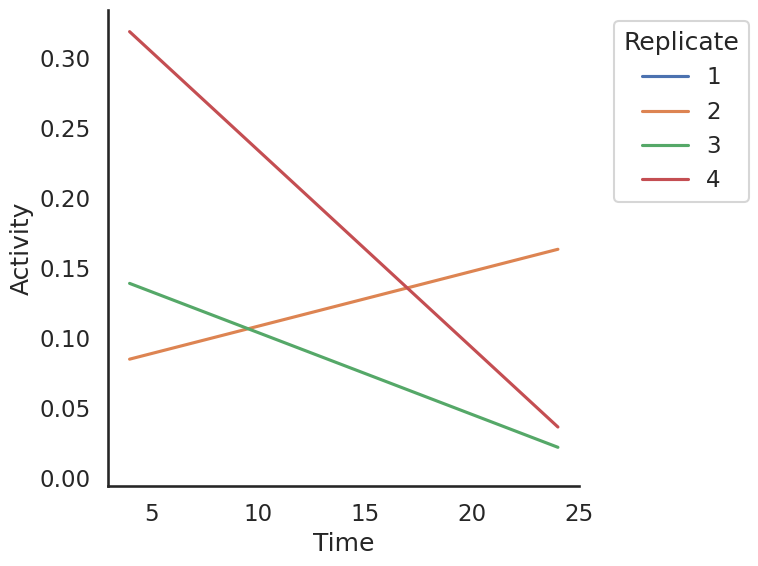

In [282]:
df = RT_aggreg_puro_trebl_results_hawk

# Randomly pick one AD
unique_ads = df['AD'].unique()
selected_ad = np.random.choice(unique_ads)

# Filter DataFrame for that AD
df_ad = df[df['AD'] == selected_ad].copy()

# Create a combined column for AD + HawkBCs
df_ad['AD_combo'] = df_ad['AD'].astype(str) + "_" + df_ad['HawkBCs'].astype(str)

# Filter by time
df_ad = df_ad[(df_ad['time'] > 0) & (df_ad['time'] < 48)]

# Plot using seaborn
plt.figure(figsize=(8,6))
sns.lineplot(
    data=df_ad,
    x='time',
    y='activity',
    hue='rep',            # automatically separates lines by replicate
    markers=True,
    dashes=False
)

plt.xlabel('Time')
plt.ylabel('Activity')
plt.legend(title='Replicate', bbox_to_anchor=(1.05,1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

In [228]:
step1 = step1_map_err_corr

def return_activities(step1):
    # --- Read in puro RT results ---
    puro_RT = pd.read_csv("../../output/NKX2-2/TL4B2/puro_only/err_corr_100/RT_trebl_experiment_results.csv")
    puro_RT["rep"] = puro_RT["name"].str.extract("_R(\d+)_")
    puro_RT["time"] = puro_RT["name"].str.extract("_T(.*)_").astype(int)
    puro_RT = puro_RT.drop(columns=['name', "RTBC_umi_count_simple"])
    
    # Merge with step1 mapping
    puro_RT_step1 = pd.merge(step1, puro_RT)
    
    # --- Read in puro AD results ---
    puro_AD = pd.read_csv("../../output/NKX2-2/TL4B2/puro_only/err_corr_100/AD_trebl_experiment_results.csv")
    puro_AD["rep"] = puro_AD["name"].str.extract("_R(\d+)_")
    puro_AD["time"] = puro_AD["name"].str.extract("_T(.*)_").astype(int)
    puro_AD = puro_AD.drop(columns=['name', "AD_umi_count_simple", "AD_ADBC_concat"])
    # Drop any extra columns if needed
    if 'remove_cols' in locals():
        puro_AD = puro_AD.drop(columns=remove_cols)
    
    # Merge with step1 mapping
    puro_AD_step1 = pd.merge(step1, puro_AD)
    puro_AD_step1
    # --- Calculate activity ---
    puro_results = pd.merge(puro_AD_step1, puro_RT_step1, how='outer').fillna(0)
    puro_results["activity"] = (puro_results["RTBC_umi_count_complex"] + 1) / (puro_results["AD_umi_count_complex"] + 1)
    
    
    # --- Determine which AD columns exist dynamically ---
    ad_cols = [col for col in ["ADBC2", "HawkBCs", "AD"] if col in puro_results.columns]
    
    # --- Aggregate RT transcripts per AD BC dynamically ---
    RT_aggreg = (
        puro_results
        .drop(columns=[col for col in ["RTBC"] if col in puro_results.columns])
        .groupby(ad_cols + ["rep", "time"])
        .sum()
        .reset_index()
    )
    RT_aggreg["activity"] = (RT_aggreg["RTBC_umi_count_complex"] + 1) / (RT_aggreg["AD_umi_count_complex"] + 1)
    
    # --- Aggregate activities per AD ---
    agg_cols = ["AD", "rep", "time"] if "AD" in RT_aggreg.columns else ad_cols + ["rep", "time"]
    RT_aggreg_activities = (
        RT_aggreg[agg_cols + ["activity"]]
        .groupby(agg_cols)
        .agg([np.mean, np.std])
        .reset_index()
        .dropna()
    )
    
    # Flatten multiindex columns
    RT_aggreg_activities.columns = [col[1] if isinstance(col, tuple) else col for col in RT_aggreg_activities.columns]
    # RT_aggreg_activities.rename(columns={"activity": "mean", "mean": "mean", "std": "std"}, inplace=True)

    ax = sns.scatterplot(data = RT_aggreg_activities, x = "mean", y = "std", edgecolor = 'none', alpha = 0.1)
    ax.set_xscale('log')
    ax.set_yscale('log')
    sns.despine()
    
    return RT_aggreg_activities

,,,,mean,std
4,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...,3,4,0.032389,0.008588
5,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...,4,24,0.008209,0.003435
6,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...,4,48,0.018635,0.020786
8,ACCGACTTCATCGACGAGGAGGTGATCATGAGCATCGTGATCGAGA...,1,4,0.992900,1.108686
9,ACCGACTTCATCGACGAGGAGGTGATCATGAGCATCGTGATCGAGA...,1,24,15.243922,20.556640
...,...,...,...,...,...
3362,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,3,24,1.556010,2.163967
3363,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,3,48,0.588047,0.624482
3365,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,4,4,0.477047,0.510775
3366,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,4,24,2.405590,2.755141


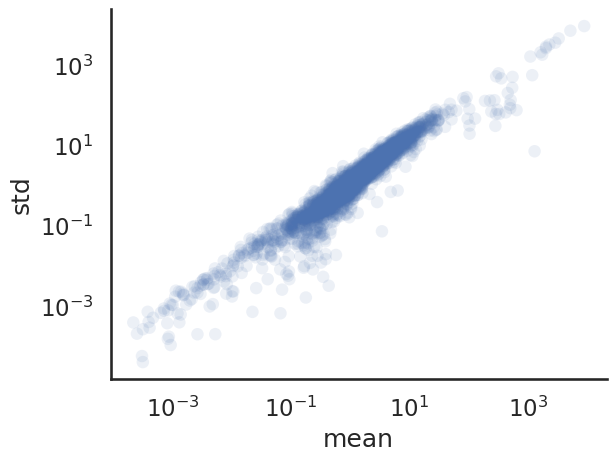

In [229]:
return_activities(step1_map_err_corr)

,,,,mean,std
5,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...,3,4,0.016471,0.004437
6,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...,4,24,0.173169,0.072733
7,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...,4,48,0.473038,0.529509
9,ACCGACTTCATCGACGAGGAGGTGCTGATGAGCCTGGTGATCGAGA...,1,4,0.417728,0.262415
10,ACCGACTTCATCGACGAGGAGGTGCTGATGAGCCTGGTGATCGAGA...,1,24,13.239203,19.210497
...,...,...,...,...,...
1894,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,3,24,2.764296,3.844534
1895,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,3,48,1.085684,1.152972
1897,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,4,4,0.455287,0.487514
1898,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,4,24,2.239392,2.564920


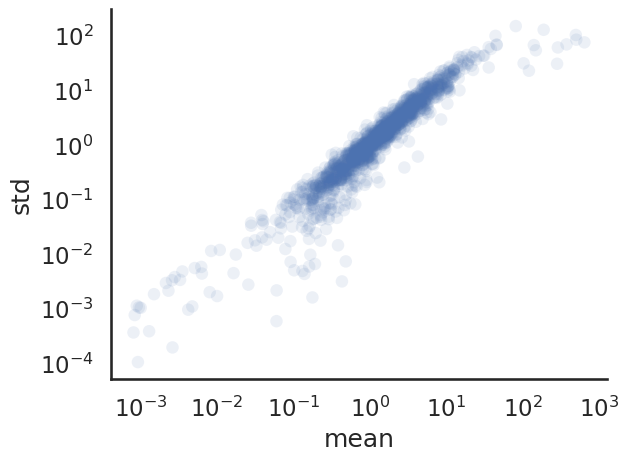

In [231]:
return_activities(step1_map_err_corr_hawk)

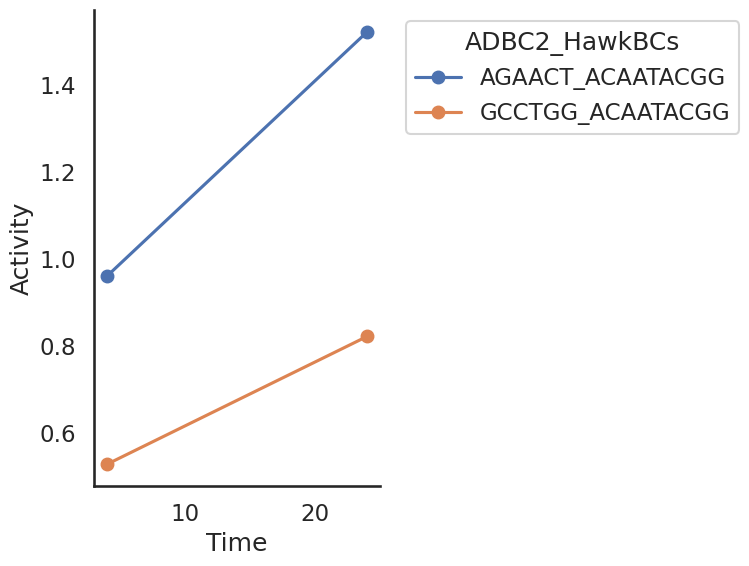

In [175]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Randomly pick one AD
unique_ads = df['AD'].unique()
selected_ad = np.random.choice(unique_ads)

# Filter DataFrame for that AD
df_ad = df[df['AD'] == selected_ad]

# Create a combined column for ADBC2 + HawkBCs
df_ad['AD_combo'] = df_ad['ADBC2'] + "_" + df_ad['HawkBCs']

# Optionally, pick a single replicate (e.g., rep=2) for clarity
df_ad = df_ad[df_ad['rep'] == "2"]
df_ad = df_ad[df_ad["time"] > 0]
df_ad = df_ad[df_ad["time"] < 48]

# Plot
plt.figure(figsize=(8,6))
for ad_combo, group in df_ad.groupby('AD_combo'):
    group_sorted = group.sort_values('time')
    plt.plot(group_sorted['time'], group_sorted['activity'], marker='o', label=ad_combo)

plt.xlabel('Time')
plt.ylabel('Activity')
plt.legend(title='ADBC2_HawkBCs', bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(False)
sns.despine()

plt.tight_layout()
plt.show()

,ADBC2,HawkBCs,AD,rep,time,AD_umi_count_complex,RTBC_umi_count_complex,activity
0,AAAAAA,ATTCTCGCC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,2,0,101.0,103.0,1.019608
1,AAAAAA,ATTCTCGCC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,2,4,162.0,191.0,1.177914
2,AAAAAA,ATTCTCGCC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,2,24,184.0,352.0,1.908108
3,AAAAAA,ATTCTCGCC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,2,48,195.0,127.0,0.653061
4,AAAAAA,ATTCTCGCC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,3,0,0.0,21.0,22.000000
...,...,...,...,...,...,...,...,...
13001,TTTTGC,ATACCGTCG,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATCAGCTTCA...,1,24,4137.0,3564.0,0.861527
13002,TTTTGC,ATACCGTCG,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATCAGCTTCA...,1,48,0.0,2766.0,2767.000000
13003,TTTTGC,ATACCGTCG,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATCAGCTTCA...,2,0,184.0,0.0,0.005405
13004,TTTTGC,ATACCGTCG,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATCAGCTTCA...,2,4,134.0,0.0,0.007407


,AD,rep,time,mean,std
7,ACCGACTTCATCGACGAGGAGGTGATCATGAGCATCGTGATCGAGA...,1,0,6.007463,8.474728
8,ACCGACTTCATCGACGAGGAGGTGATCATGAGCATCGTGATCGAGA...,1,4,0.216935,0.283608
15,ACCGACTTCATCGACGAGGAGGTGATCATGAGCATCGTGATCGAGA...,3,4,3.361345,2.923500
16,ACCGACTTCATCGACGAGGAGGTGATCATGAGCATCGTGATCGAGA...,3,24,15.024131,19.764863
18,ACCGACTTCATCGACGAGGAGGTGATCATGAGCATCGTGATCGAGA...,4,4,13.873333,18.563910
...,...,...,...,...,...
3228,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,3,24,6.836391,15.514459
3229,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,3,48,0.497808,0.343818
3231,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,4,4,32.695011,50.984190
3232,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,4,24,13.477749,31.039608


In [179]:
RT_aggreg_puro_trebl_activities["AD"].unique()[0]

'ACCGACTTCATCGACGAGGAGGTGATCATGAGCATCGTGATCGAGATGGGCATCGACAGAATCAAGGAGATTCCCGAGATCTGGATCGGCCAGAACGAGTTCGACTTCATGACCGACTTCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGCGGCAGC'

In [180]:
puro_trebl_results[puro_trebl_results["AD"] == RT_aggreg_puro_trebl_activities["AD"].unique()[2]].sort_values(by = ["rep", "time"]).set_index(["time", "rep", "ADBC2", "HawkBCs", "RTBC"]).sort_index()

AD  \
time rep ADBC2  HawkBCs   RTBC                                                                  
0    1   ATTGCA CCGATCTAT AACTCGATTCAAATAA  ACCGACTTCATCGACGAGGAGGTGCTGATGAGCCTGGTGATCGAGA...   
         CTGCGC CCGATCTAT CCGAGATACAAAATGA  ACCGACTTCATCGACGAGGAGGTGCTGATGAGCCTGGTGATCGAGA...   
         GAAATT CCGATCTAT TAATTTGACTAAGAAC  ACCGACTTCATCGACGAGGAGGTGCTGATGAGCCTGGTGATCGAGA...   
         GGAAAC CCGATCTAT AAGCTAATGGCACAGG  ACCGACTTCATCGACGAGGAGGTGCTGATGAGCCTGGTGATCGAGA...   
     2   AACAAA CCGATCTAT TGCTGAGTGTCGAATT  ACCGACTTCATCGACGAGGAGGTGCTGATGAGCCTGGTGATCGAGA...   
...                                                                                       ...   
48   4   AACAAA CCGATCTAT TGCTGAGTGTCGAATT  ACCGACTTCATCGACGAGGAGGTGCTGATGAGCCTGGTGATCGAGA...   
         ACGTGT CCGATCTAT CTAATGAAAACAGATT  ACCGACTTCATCGACGAGGAGGTGCTGATGAGCCTGGTGATCGAGA...   
         GAAATT CCGATCTAT TAATTTGACTAAGAAC  ACCGACTTCATCGACGAGGAGGTGCTGATGAGCCTGGTGATCGAGA...   
         GATAGC CCGATCTAT ATTGTGGAAAAGAAAA  ACCGACTTCATCGACGAGGAGGTGCTGATGAGCCTGGTGATCGAGA...   
         GGAAAC CCGATCTAT AAGCTAATGGCACAGG  ACCGACTTCATCGACGAGGAGGTGCTGATGAGCCTGGTGATCGAGA...   

                                            AD_umi_count_complex  \
time rep ADBC2  HawkBCs   RTBC                                     
0    1   ATTGCA CCGATCTAT AACTCGATTCAAATAA                   0.0   
         CTGCGC CCGATCTAT CCGAGATACAAAATGA                   0.0   
         GAAATT CCGATCTAT TAATTTGACTAAGAAC                 849.0   
         GGAAAC CCGATCTAT AAGCTAATGGCACAGG                   0.0   
     2   AACAAA CCGATCTAT TGCTGAGTGTCGAATT                   0.0   
...                                                          ...   
48   4   AACAAA CCGATCTAT TGCTGAGTGTCGAATT                 445.0   
         ACGTGT CCGATCTAT CTAATGAAAACAGATT                3047.0   
         GAAATT CCGATCTAT TAATTTGACTAAGAAC                4406.0   
         GATAGC CCGATCTAT ATTGTGGAAAAGAAAA                  64.0   
         GGAAAC CCGATCTAT AAGCTAATGGCACAGG                1605.0   

                                            RTBC_umi_count_complex   activity  
time rep ADBC2  HawkBCs   RTBC                                                 
0    1   ATTGCA CCGATCTAT AACTCGATTCAAATAA                    43.0  44.000000  
         CTGCGC CCGATCTAT CCGAGATACAAAATGA                    44.0  45.000000  
         GAAATT CCGATCTAT TAATTTGACTAAGAAC                   236.0   0.278824  
         GGAAAC CCGATCTAT AAGCTAATGGCACAGG                    76.0  77.000000  
     2   AACAAA CCGATCTAT TGCTGAGTGTCGAATT                    29.0  30.000000  
...                                                            ...        ...  
48   4   AACAAA CCGATCTAT TGCTGAGTGTCGAATT                   525.0   1.179372  
         ACGTGT CCGATCTAT CTAATGAAAACAGATT                  3740.0   1.227362  
         GAAATT CCGATCTAT TAATTTGACTAAGAAC                  9695.0   2.200136  
         GATAGC CCGATCTAT ATTGTGGAAAAGAAAA                   118.0   1.830769  
         GGAAAC CCGATCTAT AAGCTAATGGCACAGG                  2579.0   1.606476  

[80 rows x 4 columns]

<Axes: xlabel='mean', ylabel='std'>

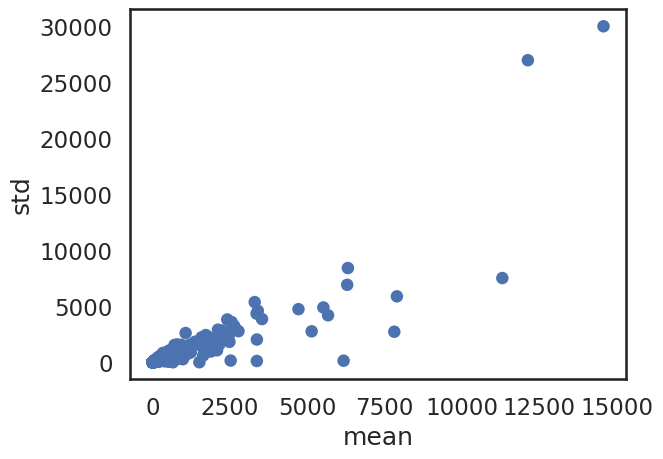

In [162]:
sns.scatterplot(data = RT_aggreg_puro_trebl_activities, x = "mean", y = "std", edgecolor = 'none')

<Axes: xlabel='mean', ylabel='std'>

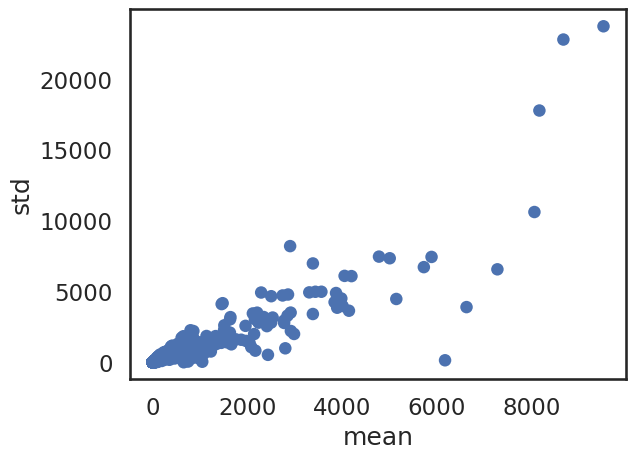

In [55]:
sns.scatterplot(data = RT_aggreg_puro_trebl_activities, x = "mean", y = "std", edgecolor = 'none')